# **TFG**

### **Análisis de Datos**
SO1: Empresas y Datos

In [1]:
# No warnings
import warnings
warnings.filterwarnings("ignore")

## **Selección de Empresa**


In [2]:
import pandas as pd

## leer los datos del Russell_2000
# excel
R2000 = pd.read_excel('russell_2000_TFG26.xlsx')
R2000

,Ticker,Name,Sector,Price,Dividend Yield,5-Year Average Dividend Yield,Dividends Per Share (TTM),Market Cap ($M),Trailing P/E Ratio,Payout Ratio,Beta,52-Week High,52-Week Low
0,AAMI,0,NaN,54.96,NaN,0.00079,0.04,1961.144870,22.3365,0.012670,1.2967,55.10,22.58
1,AAOI,0,Technology,39.33,NaN,0.00000,0.00,1111.991262,NaN,0.000000,3.0814,41.96,9.71
2,AAT,0,Real Estate,18.28,0.074398,0.07003,1.36,1118.479993,18.1935,1.330802,1.0152,23.45,15.86
3,ABCB,0,Financial Services,82.08,0.010000,0.00823,0.80,5606.623868,14.0808,0.130345,1.1680,82.33,47.86
4,ABG,0,Consumer Cyclical,253.75,NaN,0.00000,0.90,4933.041593,8.7964,0.000000,1.2050,312.56,201.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1941,ZURA,0,NaN,6.24,NaN,0.00000,0.00,75.840000,NaN,0.000000,1.3310,6.41,0.97
1942,ZVRA,0,NaN,9.01,NaN,0.00000,0.00,508.366741,14.3911,0.000000,0.9404,13.16,6.19
1943,ZWS,0,NaN,46.77,0.010000,0.00716,0.38,7830.344774,40.7194,0.315653,1.0547,49.91,27.55
1944,ZYME,0,Healthcare,23.95,NaN,0.00000,0.00,1508.761720,NaN,0.000000,0.9296,28.49,9.03


## **Leer Datos de la Empresa**

In [3]:
# leer datos de Yfinance
# !pip install yfinance

import yfinance as yf

# leer datos de VLY
empresa='VLY'
inicio='2015-01-01'
fin='2025-12-31'
periodo='1mo'

precio=yf.download(empresa, start=inicio, end=fin, interval=periodo,auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [4]:
print(precio.head())

Price      Adj Close Close  High   Low  Open    Volume
Ticker           VLY   VLY   VLY   VLY   VLY       VLY
Date                                                  
2015-01-01  5.577916  9.08  9.80  8.80  9.79  38335800
2015-02-01  5.897358  9.60  9.78  9.09  9.13  29396400
2015-03-01  5.799068  9.44  9.79  9.27  9.59  35697800
2015-04-01  5.860570  9.43  9.63  9.26  9.51  29816500
2015-05-01  6.078091  9.78  9.88  9.34  9.47  27454100


In [5]:
print(precio.tail())

Price       Adj Close  Close   High    Low   Open     Volume
Ticker            VLY    VLY    VLY    VLY    VLY        VLY
Date                                                        
2025-08-01  10.162682  10.46  10.59   8.95   9.18  162334400
2025-09-01  10.298703  10.60  11.14  10.09  10.28  189382300
2025-10-01  10.669802  10.87  11.35   9.64  10.62  331416600
2025-11-01  11.111514  11.32  11.51  10.34  10.81  170312500
2025-12-01  11.464884  11.68  12.18  11.21  11.23  129983400


### **Calcular rentabilidad logaritmica**

In [6]:
# calcular la rentabilidad mensual logaritmica
import numpy as np

rent=np.log(precio['Adj Close']/precio['Adj Close'].shift(1))

## **Visualizacion**

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1000x600 with 0 Axes>

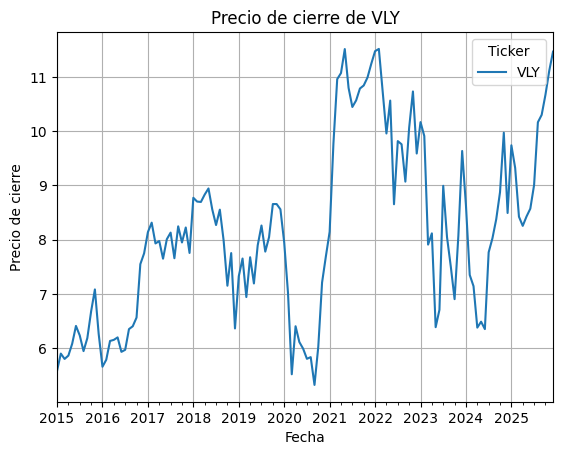

In [8]:
# Grafico del precio de VALLEY NATIONAL BANCORP.
plt.figure(figsize=(10, 6))
precio['Adj Close'].plot()
plt.title('Precio de cierre de VLY')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.grid()
plt.savefig('Precio_VLY.png') # grabar el grafico
plt.show()

<Figure size 1000x600 with 0 Axes>

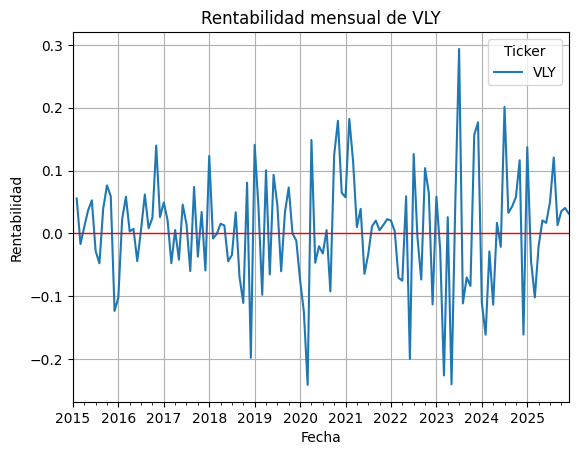

In [9]:
# Grafico de la rentabilidad de VALLEY NATIONAL BANCORP.
plt.figure(figsize=(10, 6))
rent.plot()
plt.title('Rentabilidad mensual de VLY')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad')
plt.axhline(0, color='red', lw=1) #linea en cero
plt.grid()
plt.savefig('Rentabilidad_VLY.png') # grabar el grafico
plt.show()

In [10]:
# crear un dataframe con la rentabilidad
df_rent=pd.DataFrame(rent)
df_rent.columns=['Rentabilidad']
df_rent

,Rentabilidad
Date,
2015-01-01,NaN
2015-02-01,0.055689
2015-03-01,-0.016807
2015-04-01,0.010550
2015-05-01,0.036444
...,...
2025-08-01,0.120775
2025-09-01,0.013296
2025-10-01,0.035399


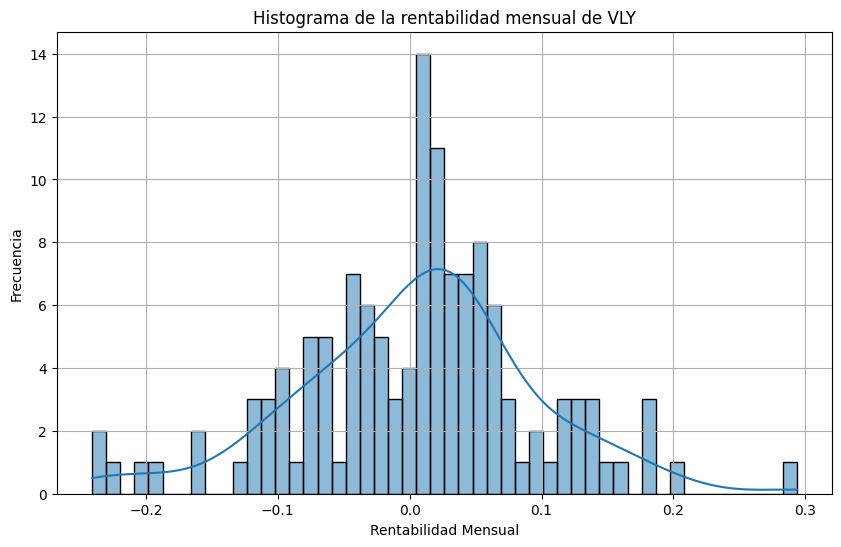

In [11]:
# Histograma de la rentabilidad mensual y densidad de probabilidad
plt.figure(figsize=(10, 6))
sns.histplot(data=df_rent, x='Rentabilidad', bins=50, kde=True)
plt.title('Histograma de la rentabilidad mensual de VLY')
plt.xlabel('Rentabilidad Mensual')
plt.ylabel('Frecuencia')
plt.grid()
plt.savefig('Histograma_Rentabilidad_VLY.png')
plt.show()

## **R2000**

El índice Russell 2000 es un índice del mercado de valores estadounidense de pequeña capitalización que constituye las 2000 acciones más pequeñas del índice Russell. Fue iniciado por Frank Russell Company en 1984. El índice lo mantiene FTSE Russell, una subsidiaria del London Stock Exchange Group.

In [12]:
# leer datos de R2000
ticker='^RUT'
inicio='2015-01-01'
fin='2025-12-31'
periodo='1mo'

indice=yf.download(ticker, start=inicio, end=fin, interval=periodo,auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


<Figure size 1000x600 with 0 Axes>

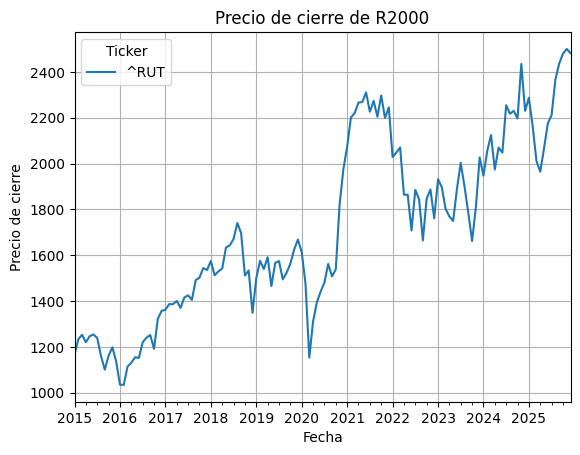

In [13]:
# Grafico del precio de R2000
plt.figure(figsize=(10, 6))
indice['Adj Close'].plot()
plt.title('Precio de cierre de R2000')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.grid()
plt.savefig('Precio_R2000.png') # grabar el grafico
plt.show()

In [14]:
# calcular la rentabilidad mensual logaritmica

rentI=np.log(indice['Adj Close']/indice['Adj Close'].shift(1))
# crear un dataframe con la rentabilidad
df_rentI=pd.DataFrame(rentI)
df_rentI.columns=['Rentabilidad']
df_rentI

,Rentabilidad
Date,
2015-01-01,NaN
2015-02-01,0.056694
2015-03-01,0.015607
2015-04-01,-0.026400
2015-05-01,0.021406
...,...
2025-08-01,0.067639
2025-09-01,0.029176
2025-10-01,0.017454


<Figure size 1000x600 with 0 Axes>

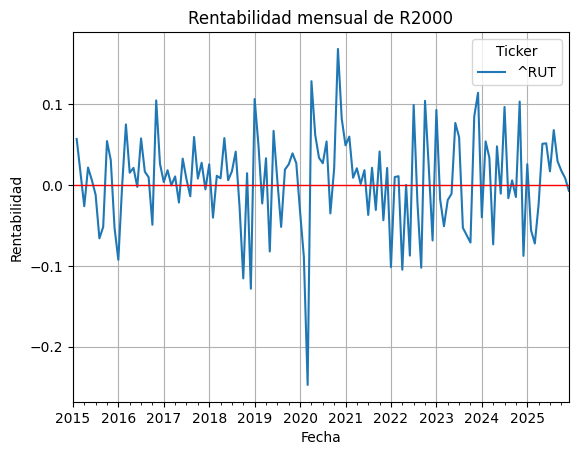

In [15]:
# Grafico de la rentabilidad de R2000
plt.figure(figsize=(10, 6))
rentI.plot()
plt.title('Rentabilidad mensual de R2000')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad')
plt.axhline(0, color='red', lw=1) #linea en zero
plt.grid()
plt.savefig('Rentabilidad_R2000.png') # grabar el grafico
plt.show()

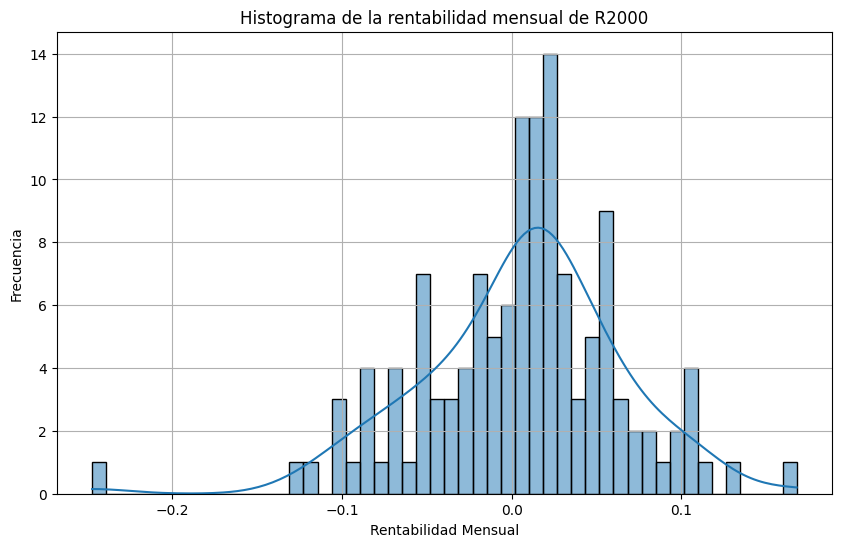

In [16]:
# Histograma de la rentabilidad mensual y densidad de probabilidad
plt.figure(figsize=(10, 6))
sns.histplot(data=df_rentI, x='Rentabilidad', bins=50, kde=True)
plt.title('Histograma de la rentabilidad mensual de R2000')
plt.xlabel('Rentabilidad Mensual')
plt.ylabel('Frecuencia')
plt.grid()
plt.savefig('Histograma_Rentabilidad_R2000.png')
plt.show()

In [17]:
# Crear un dataframe con los precios y las rentabildades
df=pd.DataFrame()
df['VLY']=precio['Adj Close']
df['R2000']=indice['Adj Close']
df['Rentabilidad_VLY']=rent
df['Rentabilidad_R2000']=rentI
df

,VLY,R2000,Rentabilidad_VLY,Rentabilidad_R2000
Date,,,,
2015-01-01,5.577916,1165.390015,NaN,NaN
2015-02-01,5.897358,1233.369995,0.055689,0.056694
2015-03-01,5.799068,1252.770020,-0.016807,0.015607
2015-04-01,5.860570,1220.130005,0.010550,-0.026400
2015-05-01,6.078091,1246.530029,0.036444,0.021406
...,...,...,...,...
2025-08-01,10.162682,2366.419922,0.120775,0.067639
2025-09-01,10.298703,2436.479980,0.013296,0.029176
2025-10-01,10.669802,2479.379883,0.035399,0.017454


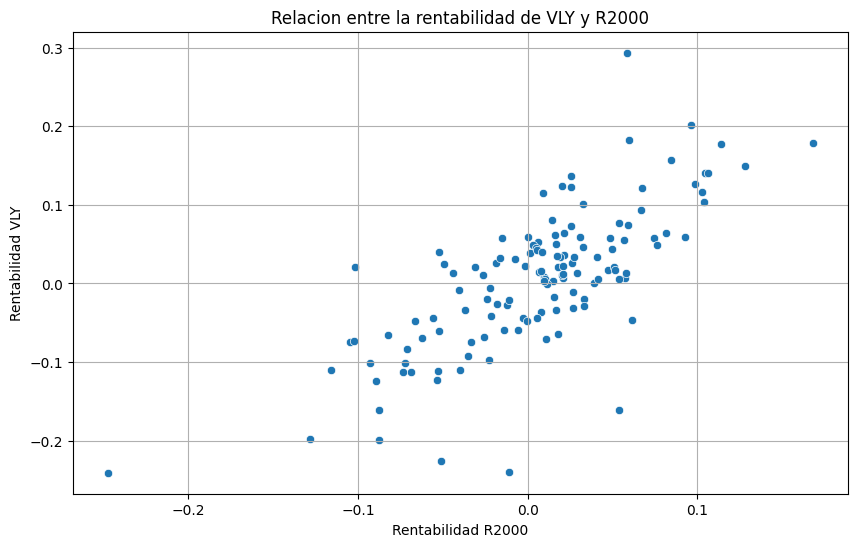

In [18]:
# scatter del russell 2000 y Valley
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rentabilidad_R2000', y='Rentabilidad_VLY')
plt.title('Relacion entre la rentabilidad de VLY y R2000')
plt.xlabel('Rentabilidad R2000')
plt.ylabel('Rentabilidad VLY')
plt.grid()
plt.savefig('VLY_R2000.png')
plt.show()

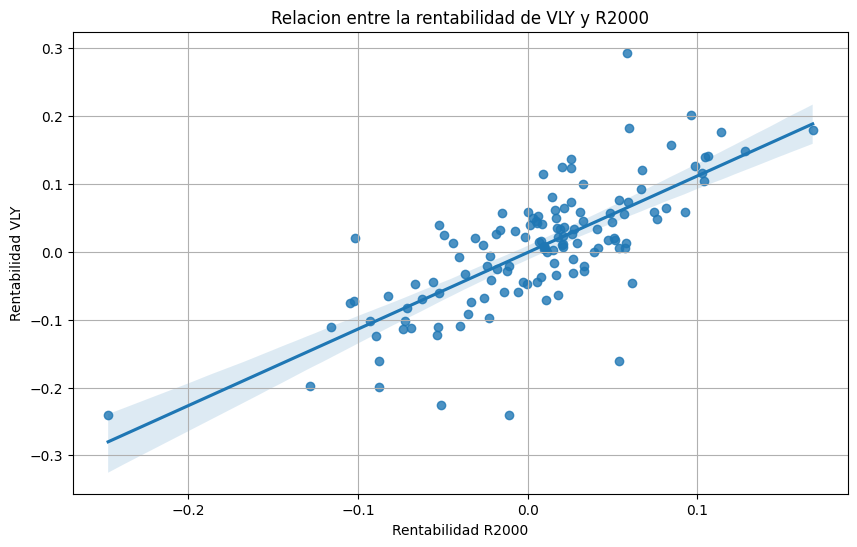

In [19]:
# scatter del russell 2000 y Valley con recta de regersión
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Rentabilidad_R2000', y='Rentabilidad_VLY')
plt.title('Relacion entre la rentabilidad de VLY y R2000')
plt.xlabel('Rentabilidad R2000')
plt.ylabel('Rentabilidad VLY')
plt.grid()
plt.savefig('VLY_R2000_recta.png')
plt.show()

In [20]:
#Guardar datos
df.to_csv('datos_VLY_tfg.csv', index=True)

# **Analisis de Fundamental**
- https://ir.valleynationalbank.com/overview/default.aspx
- https://www.alphaspread.com/security/nasdaq/vly/summary
- https://www.marketscreener.com/quote/stock/VALLEY-NATIONAL-BANCORP-46555706/ratings/

### **SO2:**

In [21]:
import pandas as pd
import numpy as np
import datetime

In [22]:
# Definir el período de 10 años
end_date = '2025-12-31'
start_date = '2015-01-01'

In [23]:
returns = pd.read_csv('datos_VLY_tfg.csv')
#index date
returns['Date'] = pd.to_datetime(returns['Date'])
returns.set_index('Date', inplace=True)
returns

,VLY,R2000,Rentabilidad_VLY,Rentabilidad_R2000
Date,,,,
2015-01-01,5.577916,1165.390015,NaN,NaN
2015-02-01,5.897358,1233.369995,0.055689,0.056694
2015-03-01,5.799068,1252.770020,-0.016807,0.015607
2015-04-01,5.860570,1220.130005,0.010550,-0.026400
2015-05-01,6.078091,1246.530029,0.036444,0.021406
...,...,...,...,...
2025-08-01,10.162682,2366.419922,0.120775,0.067639
2025-09-01,10.298703,2436.479980,0.013296,0.029176
2025-10-01,10.669802,2479.379883,0.035399,0.017454


In [24]:
# !pip install pandas-datareader
# Obtener datos de Fama-French (descarga desde web)
import pandas_datareader.data as web
# Obtener datos de Fama-French desde DataReader
fama_french = web.DataReader("F-F_Research_Data_Factors", "famafrench", start_date, end_date)[0]

# Convertir índice a formato de fecha
fama_french.index = fama_french.index.to_timestamp()

# Convertir retornos de Fama-French a porcentajes
fama_french = fama_french / 100

In [25]:
import pandas_datareader.data as web

# Alinear fechas con Fama-French
# Ensure 'returns' does not have overlapping Fama-French columns before joining
ff_cols = ['Mkt-RF', 'SMB', 'HML', 'RF']
for col in ff_cols:
    if col in returns.columns:
        returns = returns.drop(columns=[col])

returns = returns.join(fama_french, how="inner")

# Calcular primas de mercado y de Shake Shack
returns["Market Premium"] = returns["Rentabilidad_R2000"] - returns["RF"]
returns["VLY Premium"] = returns["Rentabilidad_VLY"] - returns["RF"]

# Mostrar resultados
returns

,VLY,R2000,Rentabilidad_VLY,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,VLY Premium
Date,,,,,,,,,,
2015-01-01,5.577916,1165.390015,NaN,NaN,-0.0310,-0.0059,-0.0345,0.0000,NaN,NaN
2015-02-01,5.897358,1233.369995,0.055689,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,0.055689
2015-03-01,5.799068,1252.770020,-0.016807,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,-0.016807
2015-04-01,5.860570,1220.130005,0.010550,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,0.010550
2015-05-01,6.078091,1246.530029,0.036444,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,0.036444
...,...,...,...,...,...,...,...,...,...,...
2025-08-01,10.162682,2366.419922,0.120775,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.116975
2025-09-01,10.298703,2436.479980,0.013296,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.009996
2025-10-01,10.669802,2479.379883,0.035399,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,0.031699


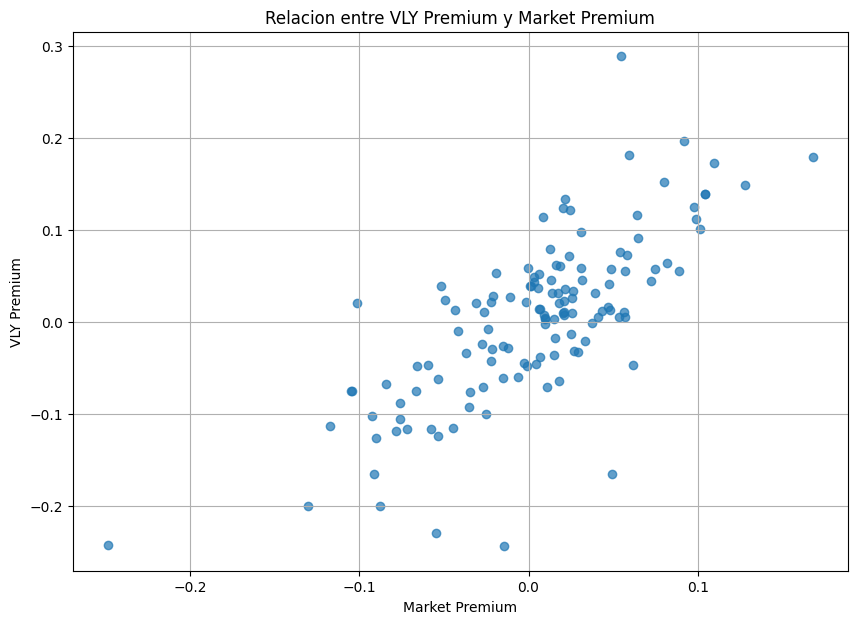

In [26]:
# Gráfico XY
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(returns["Market Premium"], returns["VLY Premium"], alpha=0.7)
plt.xlabel("Market Premium")
plt.ylabel("VLY Premium")
plt.title("Relacion entre VLY Premium y Market Premium")
plt.grid(True)
plt.show()

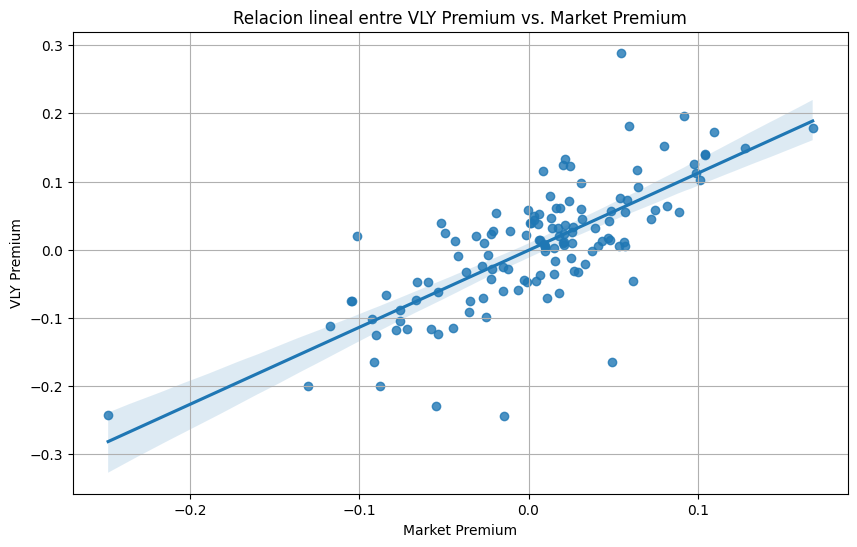

In [27]:
# Grafico con regresión lineal usando sns.regplot
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.regplot(x="Market Premium", y="VLY Premium", data=returns)
plt.xlabel("Market Premium")
plt.ylabel("VLY Premium")
plt.title("Relacion lineal entre VLY Premium vs. Market Premium")
plt.grid(True)
plt.show()

In [28]:
# Estimar la regresión
import statsmodels.api as sm
modelo_capm = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium']", data=returns).fit()
modelo_capm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.550
Model:                                OLS   Adj. R-squared:                  0.546
Method:                     Least Squares   F-statistic:                     157.5
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           4.20e-24
Time:                            11:42:17   Log-Likelihood:                 182.60
No. Observations:                     131   AIC:                            -361.2
Df Residuals:                         129   BIC:                            -355.5
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0008      0.005     -0.153      0.878      -0.011       0.010
returns['Market Premium']     1.1299      0.090     12.549      0.000       0.952       1.308
==============================================================================
Omnibus:                       16.951   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.822
Skew:                          -0.293   Prob(JB):                     7.56e-13
Kurtosis:                       6.144   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

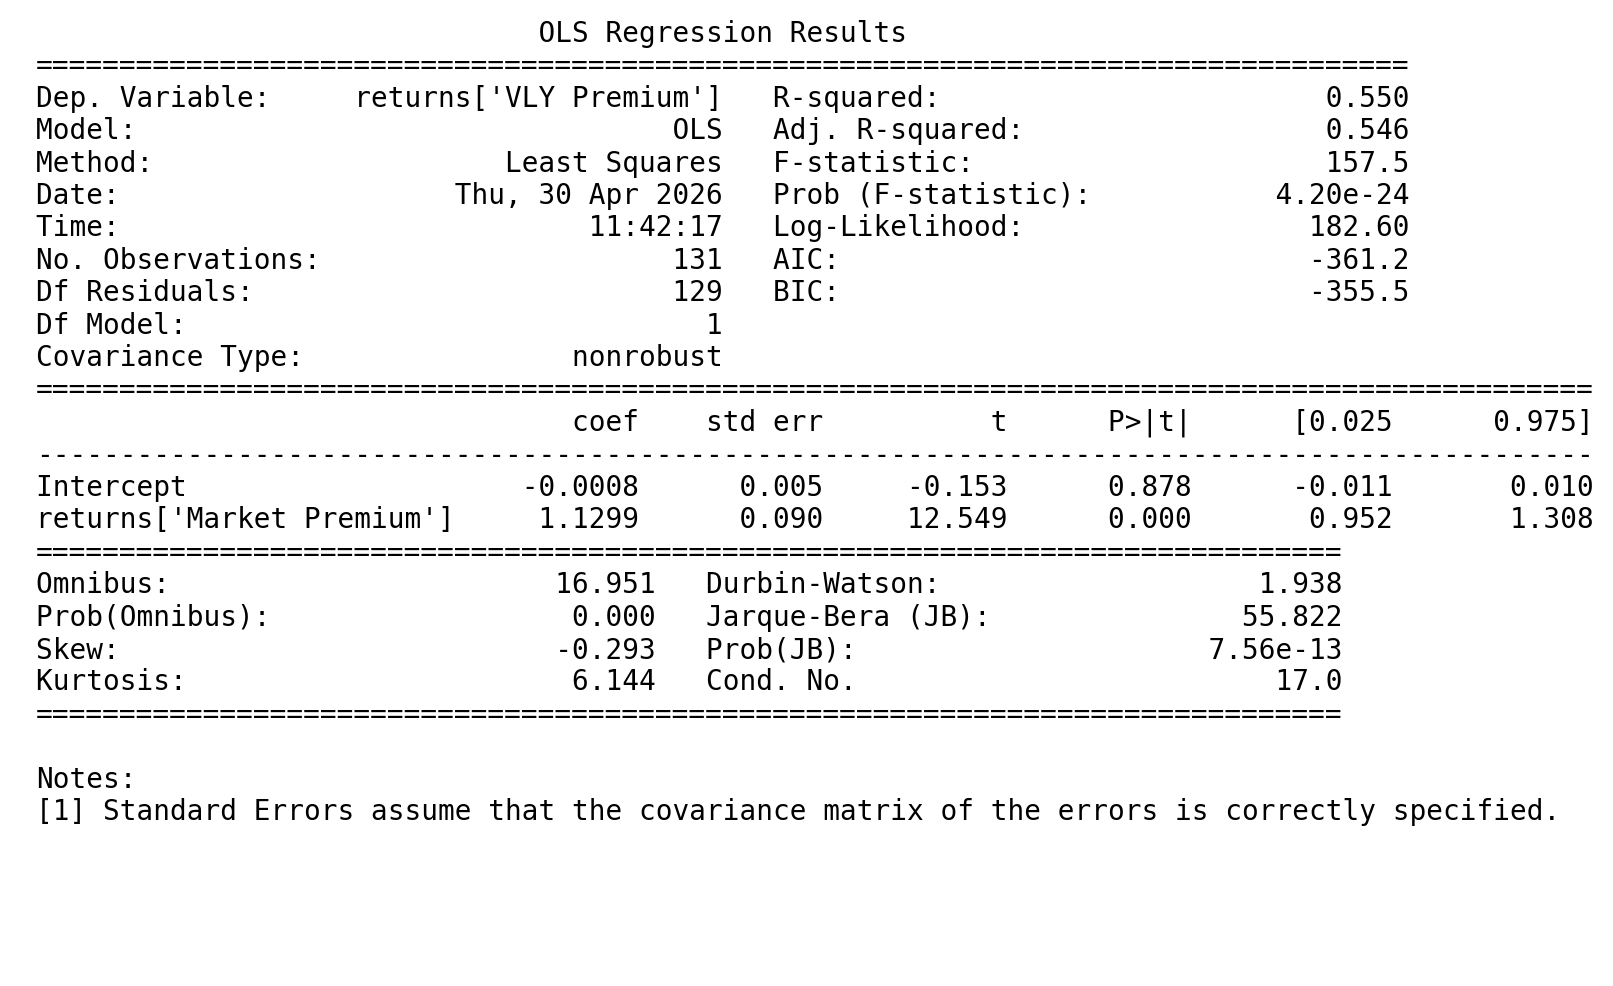

In [29]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.99, modelo_capm.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_01.png')

In [30]:
# save data como dataframe
returns.to_csv('returns_VLY.csv')

## **S03: Análisis de Residuos**

In [31]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [32]:
# leer datos
returns = pd.read_csv('returns_VLY.csv')

In [33]:
returns

,Date,VLY,R2000,Rentabilidad_VLY,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,VLY Premium
0,2015-01-01,5.577916,1165.390015,NaN,NaN,-0.0310,-0.0059,-0.0345,0.0000,NaN,NaN
1,2015-02-01,5.897358,1233.369995,0.055689,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,0.055689
2,2015-03-01,5.799068,1252.770020,-0.016807,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,-0.016807
3,2015-04-01,5.860570,1220.130005,0.010550,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,0.010550
4,2015-05-01,6.078091,1246.530029,0.036444,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,0.036444
...,...,...,...,...,...,...,...,...,...,...,...
127,2025-08-01,10.162682,2366.419922,0.120775,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.116975
128,2025-09-01,10.298703,2436.479980,0.013296,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.009996
129,2025-10-01,10.669802,2479.379883,0.035399,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,0.031699
130,2025-11-01,11.111514,2500.429932,0.040564,0.008454,-0.0013,0.0038,0.0376,0.0030,0.005454,0.037564


In [34]:
# Eliminar NA`s
returns=returns.dropna()

In [35]:
# Estimar la regresión
import statsmodels.api as sm
modelo_capm = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium']", data=returns).fit()
modelo_capm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.550
Model:                                OLS   Adj. R-squared:                  0.546
Method:                     Least Squares   F-statistic:                     157.5
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           4.20e-24
Time:                            11:42:17   Log-Likelihood:                 182.60
No. Observations:                     131   AIC:                            -361.2
Df Residuals:                         129   BIC:                            -355.5
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0008      0.005     -0.153      0.878      -0.011       0.010
returns['Market Premium']     1.1299      0.090     12.549      0.000       0.952       1.308
==============================================================================
Omnibus:                       16.951   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.822
Skew:                          -0.293   Prob(JB):                     7.56e-13
Kurtosis:                       6.144   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

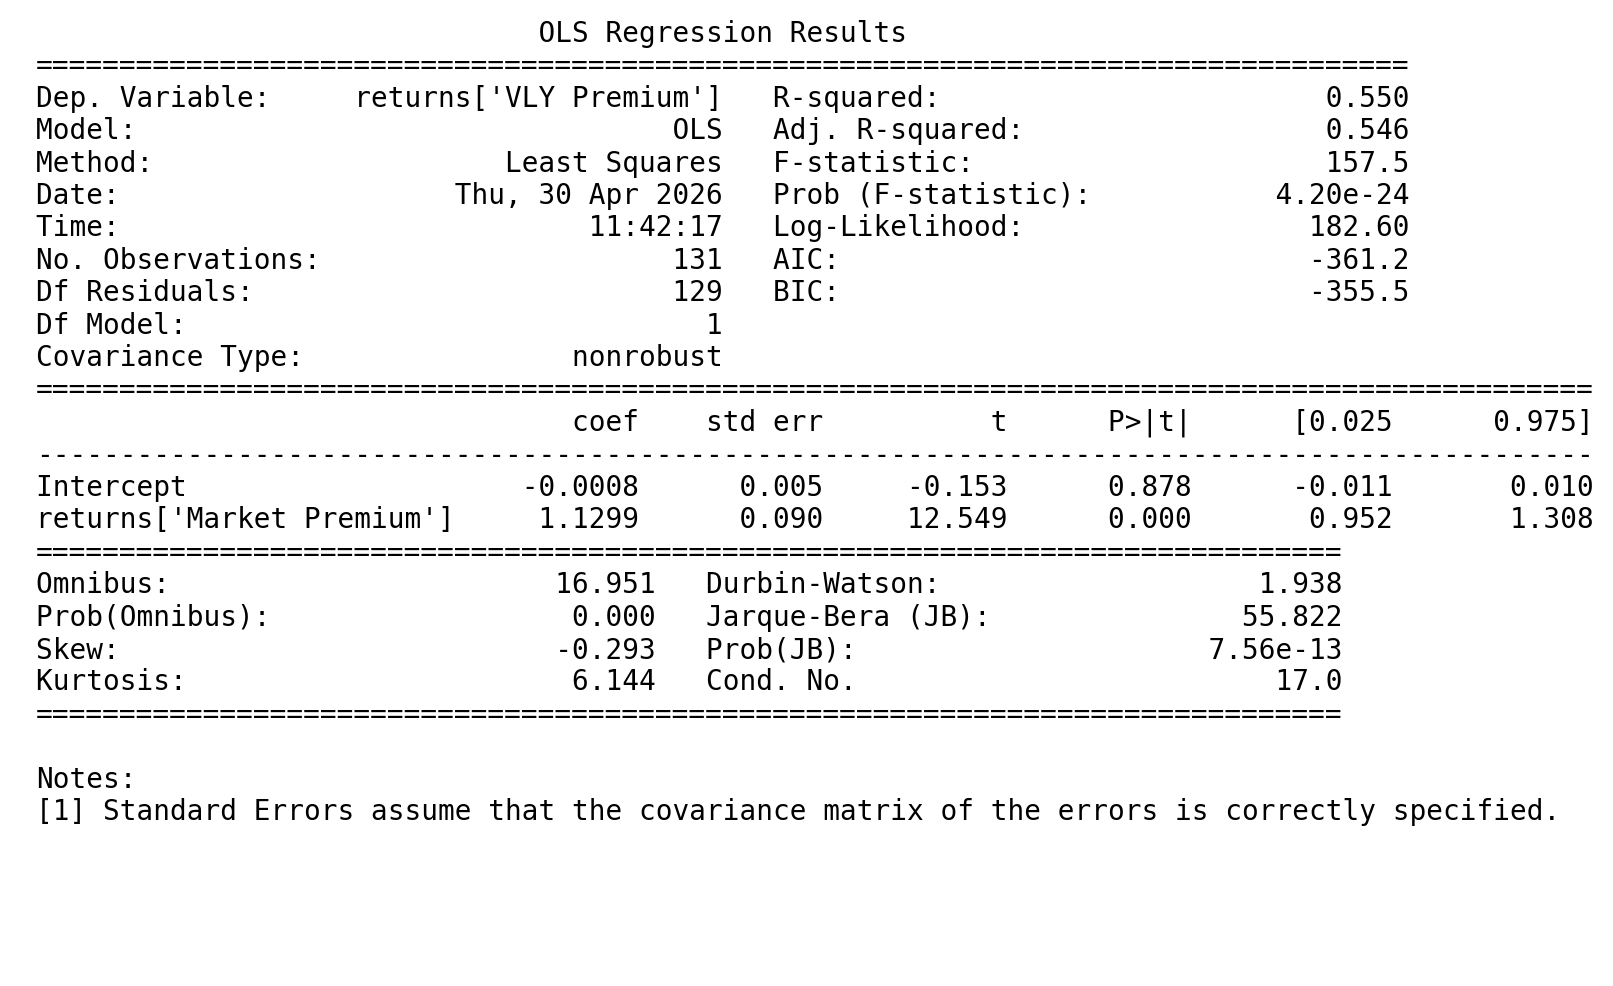

In [36]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.99, modelo_capm.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_01.png')

In [37]:
# Generar los residuos
returns.index=returns['Date']
returns['residuos'] = modelo_capm.resid.values
returns

,Date,VLY,R2000,Rentabilidad_VLY,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,VLY Premium,residuos
Date,,,,,,,,,,,,
2015-02-01,2015-02-01,5.897358,1233.369995,0.055689,0.056694,0.0613,0.0061,-0.0179,0.0000,0.056694,0.055689,-0.007554
2015-03-01,2015-03-01,5.799068,1252.770020,-0.016807,0.015607,-0.0111,0.0305,-0.0038,0.0000,0.015607,-0.016807,-0.033628
2015-04-01,2015-04-01,5.860570,1220.130005,0.010550,-0.026400,0.0059,-0.0299,0.0180,0.0000,-0.026400,0.010550,0.041191
2015-05-01,2015-05-01,6.078091,1246.530029,0.036444,0.021406,0.0137,0.0095,-0.0111,0.0000,0.021406,0.036444,0.013071
2015-06-01,2015-06-01,6.407476,1253.949951,0.052775,0.005935,-0.0152,0.0294,-0.0082,0.0000,0.005935,0.052775,0.046882
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,2025-08-01,10.162682,2366.419922,0.120775,0.067639,0.0184,0.0387,0.0442,0.0038,0.063839,0.116975,0.045659
2025-09-01,2025-09-01,10.298703,2436.479980,0.013296,0.029176,0.0339,-0.0185,-0.0105,0.0033,0.025876,0.009996,-0.018428
2025-10-01,2025-10-01,10.669802,2479.379883,0.035399,0.017454,0.0196,-0.0055,-0.0310,0.0037,0.013754,0.031699,0.016972


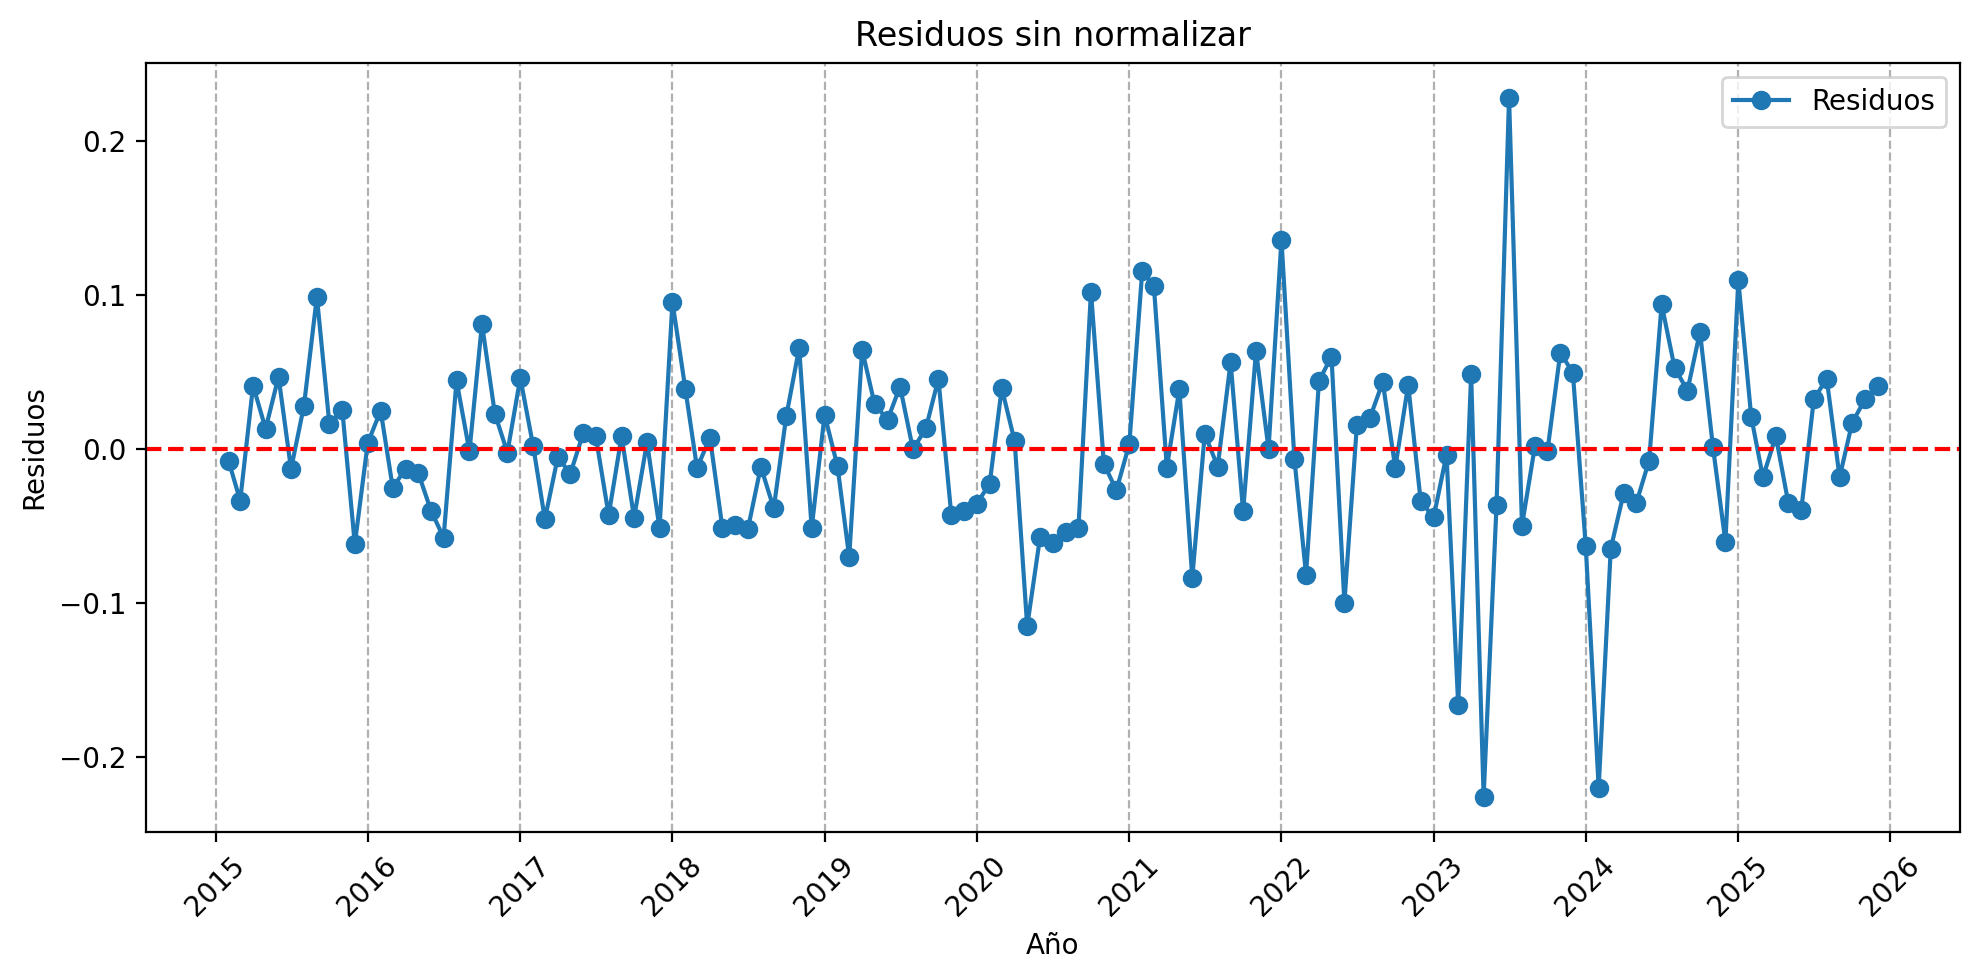

In [38]:
import matplotlib.dates as mdates

# Primero,  el índice sea de tipo datetime
if not isinstance(returns.index, pd.DatetimeIndex):
    # Si tu índice no es de tipo datetime, conviértelo
    returns.index = pd.to_datetime(returns.index)

# Configuración de los ticks y el grid en el inicio de cada año
year_locator = mdates.YearLocator()  # Localizador para cada inicio de año
year_formatter = mdates.DateFormatter('%Y')  # Formateador para mostrar solo el año

# Graficar residuos sin normalizar
plt.figure(figsize=(10, 5))
plt.plot(returns['residuos'], marker='o', linestyle='-', label='Residuos')
plt.axhline(0, color='red', linestyle='--')

# Configurar el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(year_locator)  # Ticks en cada año
ax.xaxis.set_major_formatter(year_formatter)  # Mostrar solo el año
plt.grid(True, which='major', axis='x', linestyle='--')  # Grid en los inicios de año

# Rotar las etiquetas del eje x si  para mayor claridad
plt.xticks(rotation=45)

plt.title('Residuos sin normalizar')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.legend()
plt.tight_layout()  # Ajustar el diseño para evitar recortes
plt.savefig('residuos_sin_normalizar.png') # grabar el grafico
plt.show()

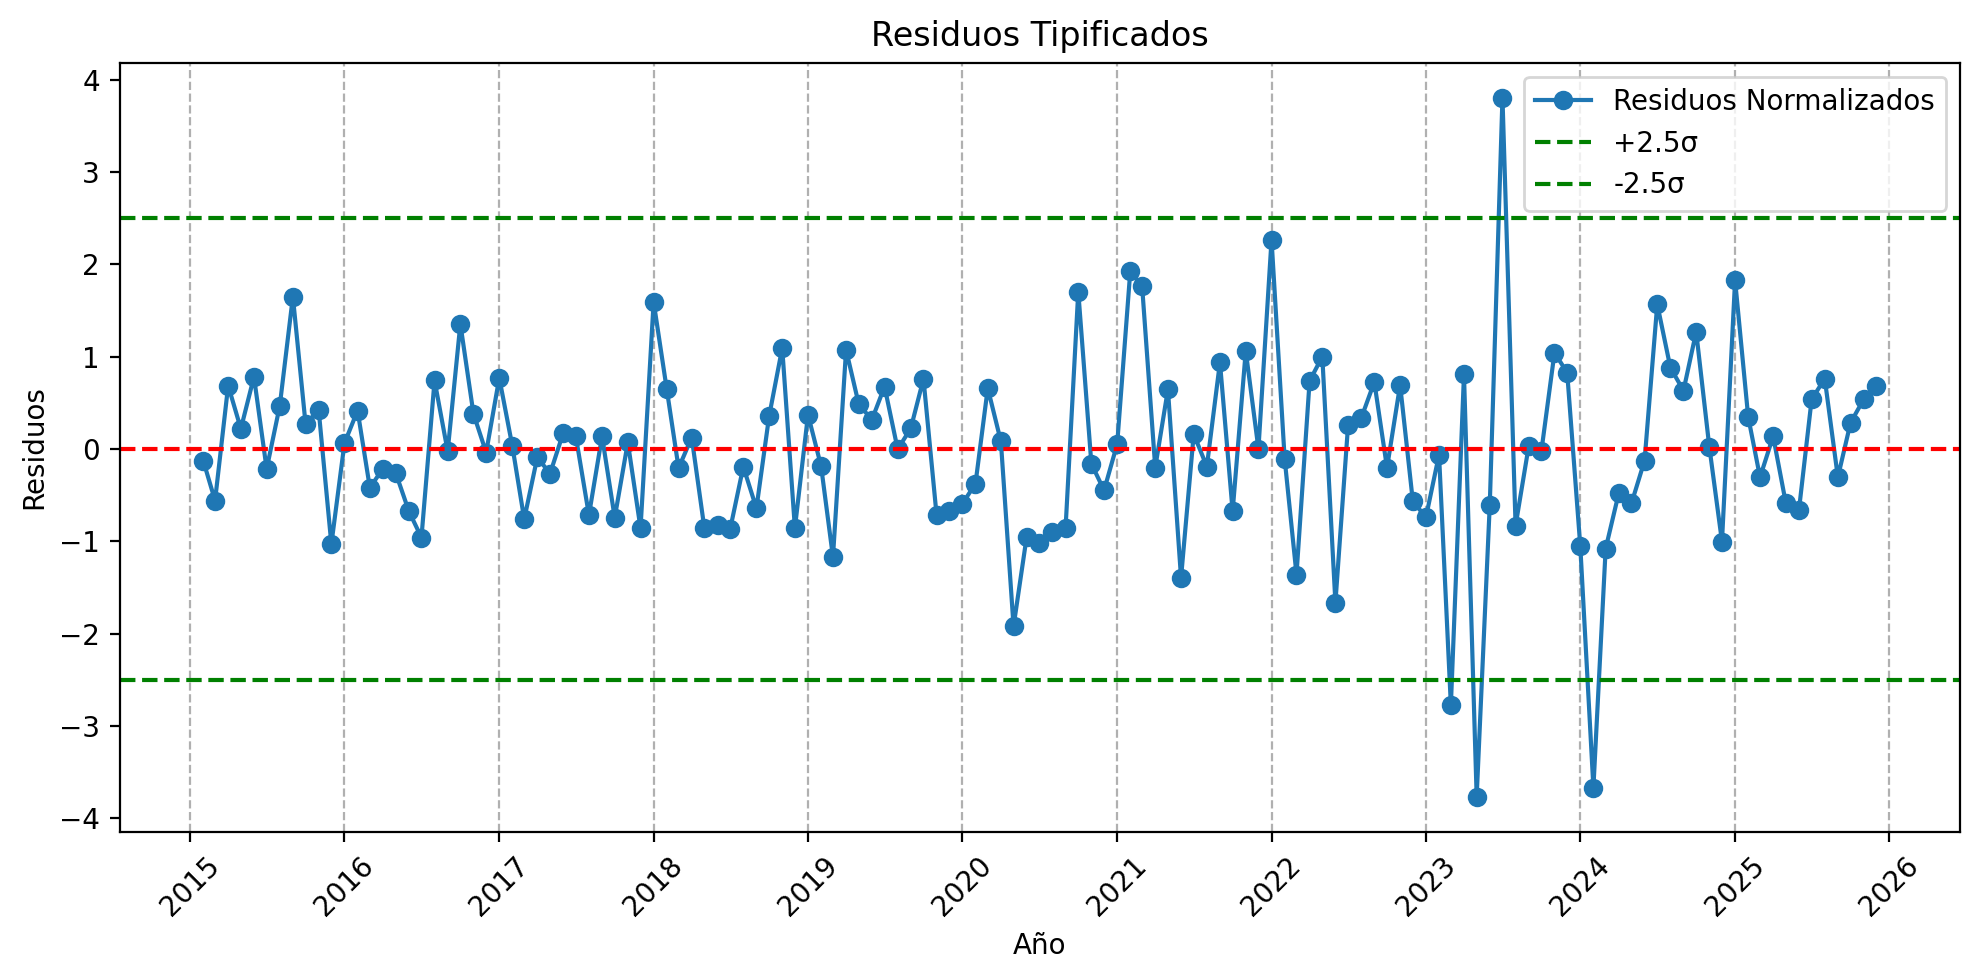

In [39]:
# Normalización de los residuos
returns['residuos_normalizados'] = (returns['residuos'] - np.mean(returns['residuos'])) / np.std(returns['residuos'])

plt.figure(figsize=(10, 5))
plt.plot(returns['residuos_normalizados'], marker='o', linestyle='-', label='Residuos Normalizados')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2.5, color='green', linestyle='--', label='+2.5σ')
plt.axhline(-2.5, color='green', linestyle='--', label='-2.5σ')

# Configurar el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(year_locator)  # Ticks en cada año
ax.xaxis.set_major_formatter(year_formatter)  # Mostrar solo el año
plt.grid(True, which='major', axis='x', linestyle='--')  # Grid en los inicios de año

# Rotar las etiquetas del eje x si  para mayor claridad
plt.xticks(rotation=45)

plt.title('Residuos Tipificados')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.legend()
plt.tight_layout()  # Ajustar el diseño para evitar recortes
plt.savefig('residuos_tipificados.png') # grabar el grafico
plt.show()

### **Normalidad**

In [40]:
import scipy.stats as stats

from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns

# Obtener los residuos
residuos = modelo_capm.resid

# 1. Análisis de Normalidad
# ------------------------

# Test de Jarque-Bera para normalidad
jb_test = sm.stats.jarque_bera(residuos)
print(f"Test de Jarque-Bera:")
print(f"Estadístico: {jb_test[0]:.4f}")
print(f"p-valor: {jb_test[1]:.4f}")
print(f"Normalidad: {'Se rechaza' if jb_test[1] < 0.05 else 'No se rechaza'}")
print("\n")

Test de Jarque-Bera:
Estadístico: 55.8217
p-valor: 0.0000
Normalidad: Se rechaza




<Figure size 2000x1200 with 0 Axes>

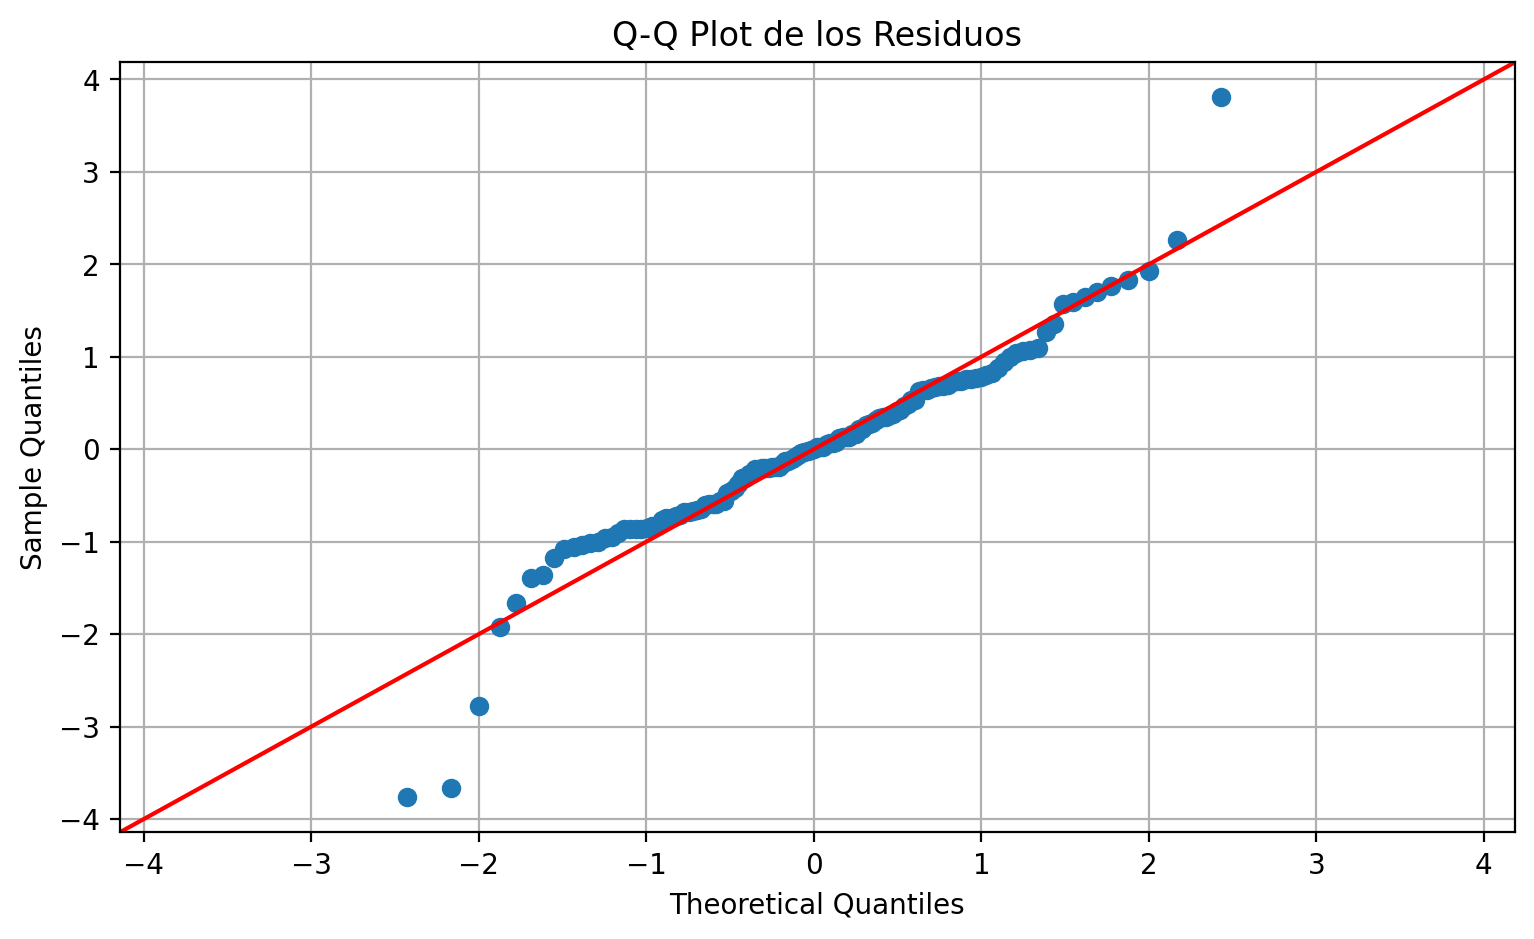

In [41]:
# Gráfico Q-Q Plot
plt.figure(figsize=(10, 6))
fig = sm.qqplot(residuos, stats.norm, line='45', fit=True)
plt.title('Q-Q Plot de los Residuos')
plt.grid(True)
plt.savefig('residuos_qqplot.png') # grabar el grafico
plt.show()

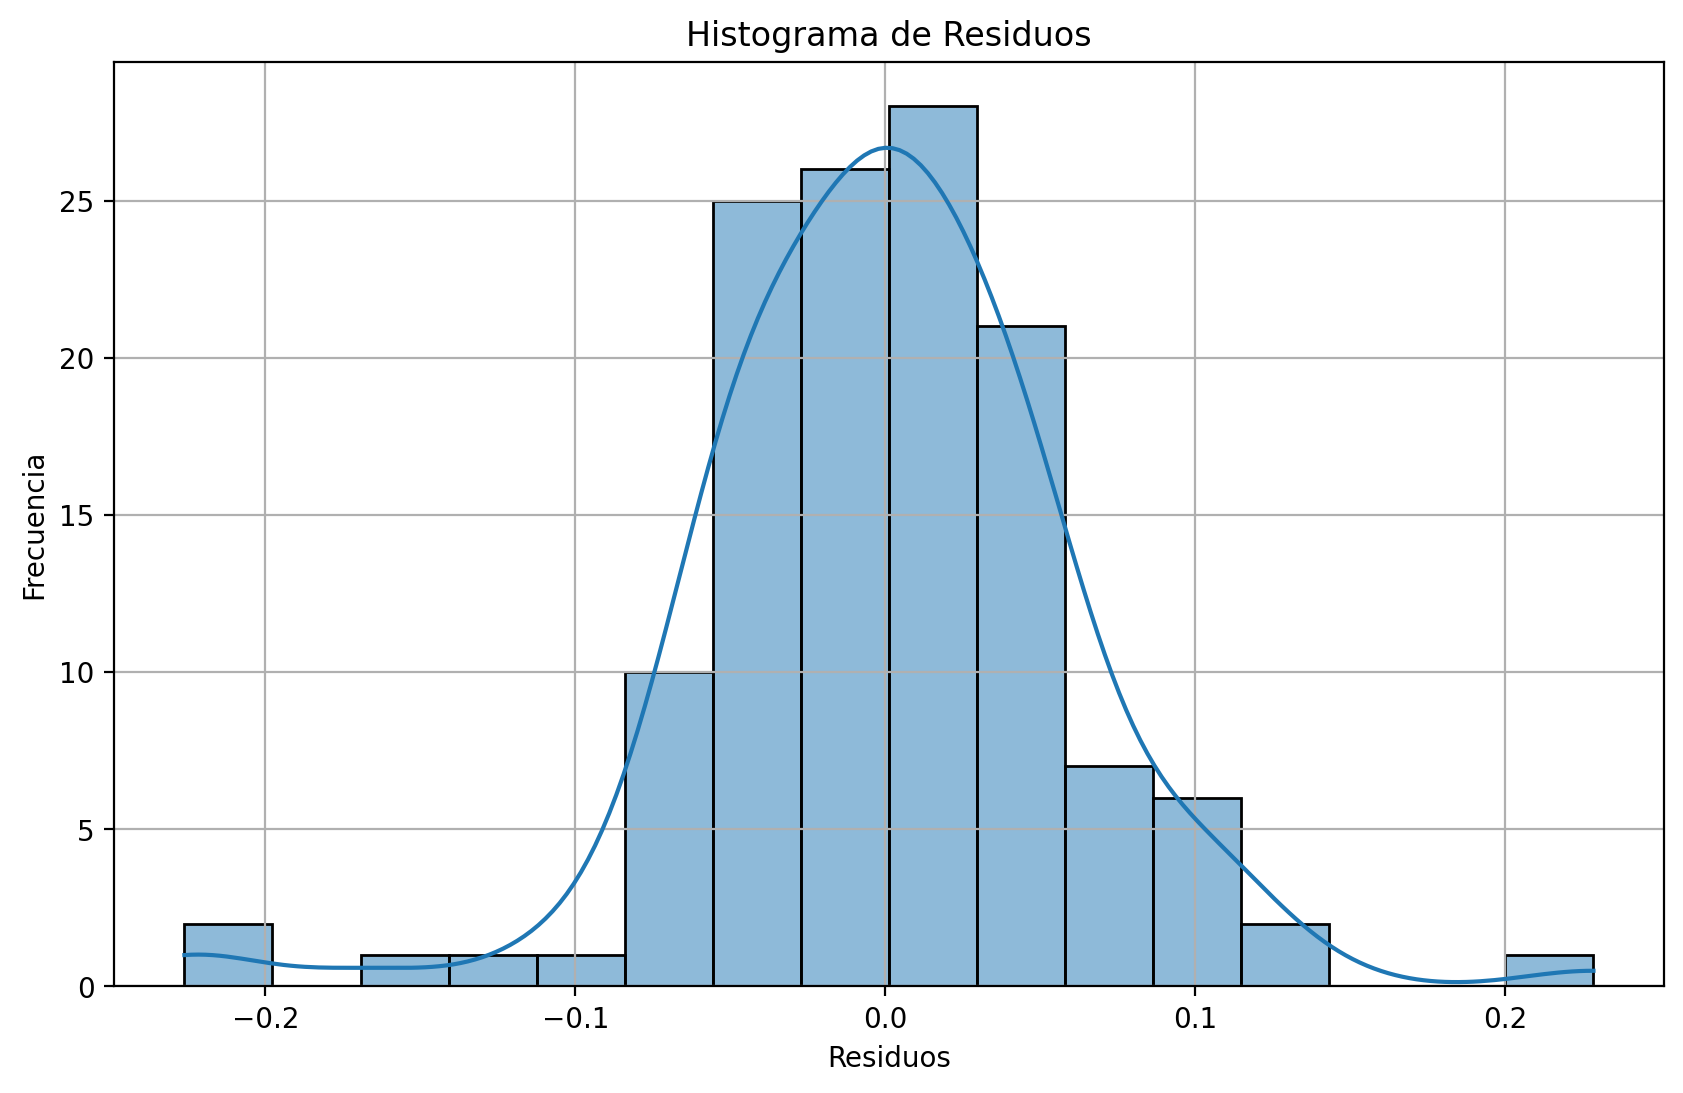

In [42]:
# Histograma de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.savefig('residuos_histograma.png') # grabar el grafico
plt.show()

## **Heterocedasticidad**

In [43]:
# 2. Análisis de Heterocedasticidad

# Test de Breusch-Pagan
bp_test = het_breuschpagan(residuos, modelo_capm.model.exog)
print(f"Test de Breusch-Pagan para Heterocedasticidad:")
print(f"Estadístico LM: {bp_test[0]:.4f}")
print(f"p-valor: {bp_test[1]:.4f}")
print(f"Homocedasticidad: {'Se rechaza' if bp_test[1] < 0.05 else 'No se rechaza'}")
print("\n")

Test de Breusch-Pagan para Heterocedasticidad:
Estadístico LM: 0.0054
p-valor: 0.9414
Homocedasticidad: No se rechaza




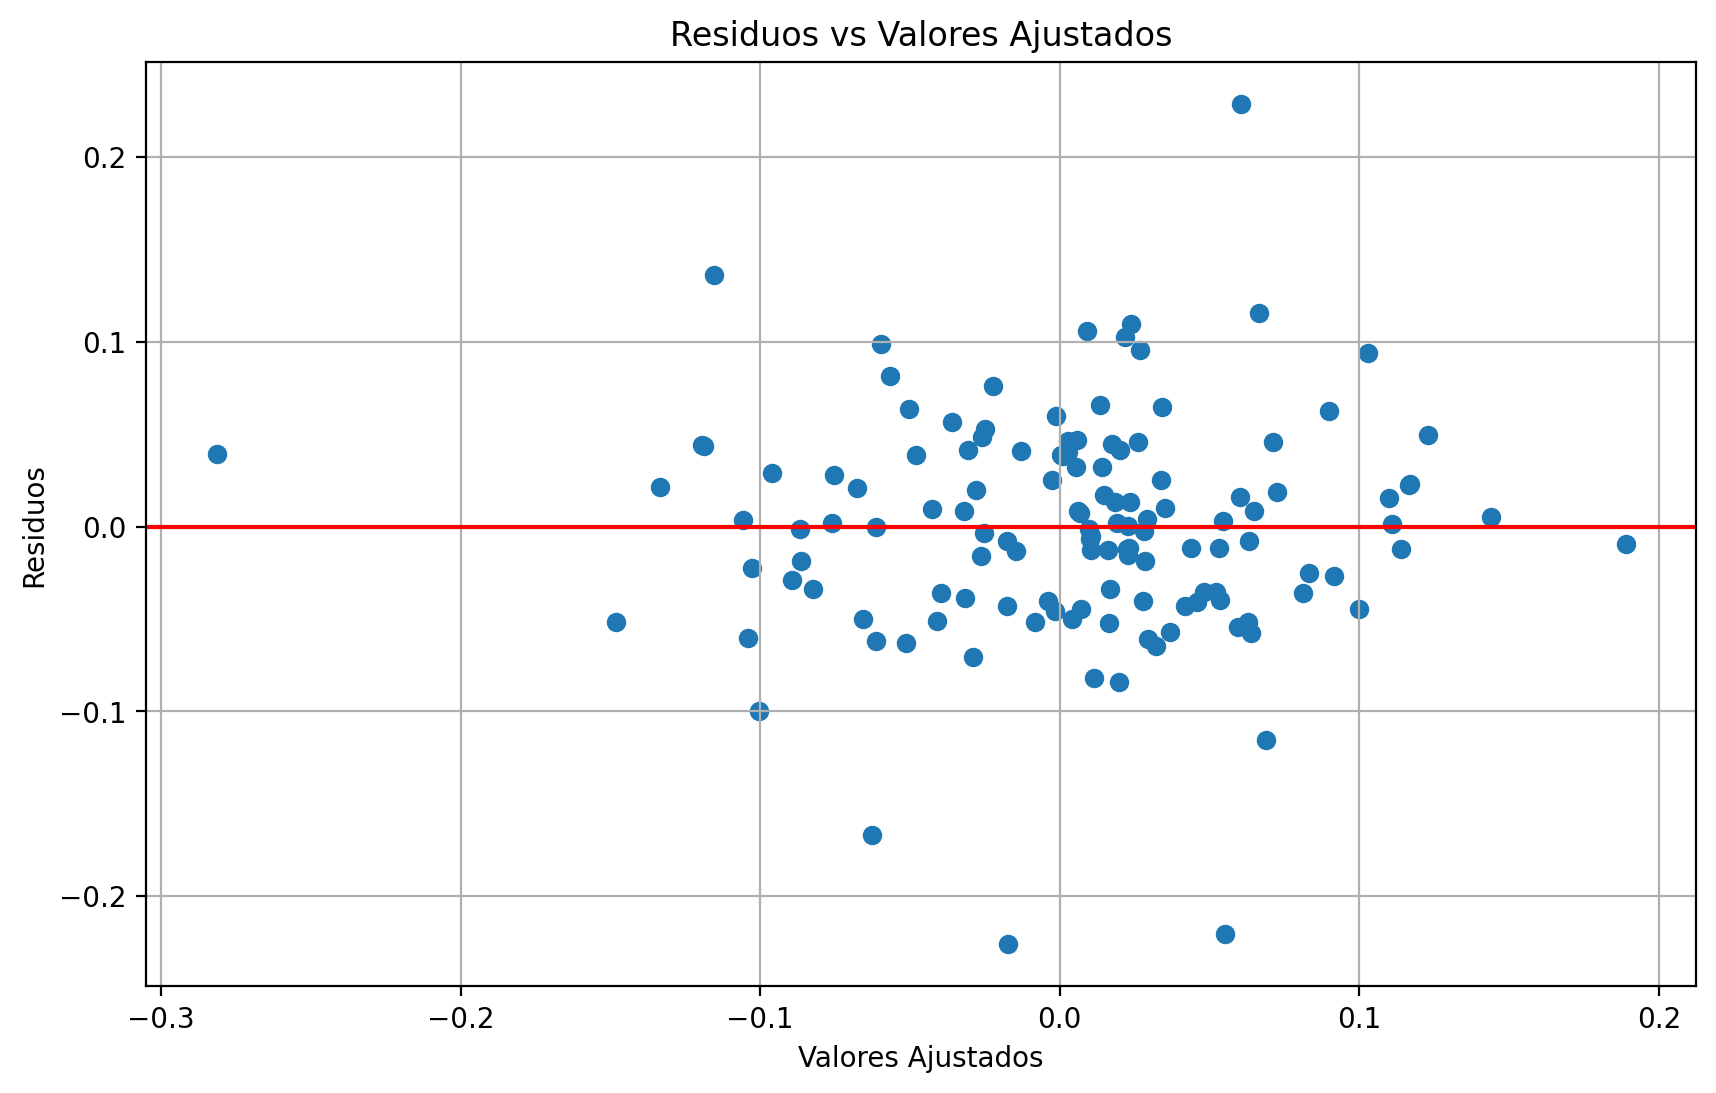

In [44]:
# Gráfico de residuos vs valores ajustados
plt.figure(figsize=(10, 6))
plt.scatter(modelo_capm.fittedvalues, residuos)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Residuos vs Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.grid(True)
plt.savefig('residuos_valoresajustados.png') # grabar el grafico
plt.show()

In [45]:
from statsmodels.stats.diagnostic import het_white

# Realizar el test de White para heterocedasticidad
white_test = het_white(modelo_capm.resid, modelo_capm.model.exog)

# Mostrar los resultados
nombres = ['Estadístico LM', 'p-valor LM', 'Estadístico F', 'p-valor F']
print("Test de White para heterocedasticidad:")
for nombre, valor in zip(nombres, white_test):
    print(f"{nombre}: {valor:.4f}")

# Interpretación del resultado
alpha = 0.05
if white_test[1] < alpha:
    print(f"\nCon un nivel de significación de {alpha}, se rechaza la hipótesis nula.")
    print("Por lo tanto, hay evidencia de heterocedasticidad en los residuos.")
else:
    print(f"\nCon un nivel de significación de {alpha}, no se rechaza la hipótesis nula.")
    print("Por lo tanto, no hay evidencia suficiente de heterocedasticidad en los residuos.")

Test de White para heterocedasticidad:
Estadístico LM: 0.2076
p-valor LM: 0.9014
Estadístico F: 0.1016
p-valor F: 0.9035

Con un nivel de significación de 0.05, no se rechaza la hipótesis nula.
Por lo tanto, no hay evidencia suficiente de heterocedasticidad en los residuos.


## **Autocorrelación**

In [46]:
# 3. Análisis de Autocorrelación
# Test de Ljung-Box
lb_test = acorr_ljungbox(residuos, lags=12)  # 12 lags para datos mensuales

print(f"Test de Ljung-Box para Autocorrelación:")
for i, row in lb_test.iterrows():
        print(f"Lag {i}: Estadístico: {row['lb_stat']:.4f}, p-valor: {row['lb_pvalue']:.4f}")
        print(f"Autocorrelación: {'Presente' if any(p < 0.05 for p in lb_test['lb_pvalue']) else 'No detectada'}")


Test de Ljung-Box para Autocorrelación:
Lag 1: Estadístico: 0.1126, p-valor: 0.7372
Autocorrelación: No detectada
Lag 2: Estadístico: 0.2068, p-valor: 0.9018
Autocorrelación: No detectada
Lag 3: Estadístico: 0.8071, p-valor: 0.8478
Autocorrelación: No detectada
Lag 4: Estadístico: 1.7553, p-valor: 0.7806
Autocorrelación: No detectada
Lag 5: Estadístico: 2.2223, p-valor: 0.8176
Autocorrelación: No detectada
Lag 6: Estadístico: 4.0668, p-valor: 0.6676
Autocorrelación: No detectada
Lag 7: Estadístico: 8.8380, p-valor: 0.2645
Autocorrelación: No detectada
Lag 8: Estadístico: 9.6121, p-valor: 0.2933
Autocorrelación: No detectada
Lag 9: Estadístico: 10.7188, p-valor: 0.2955
Autocorrelación: No detectada
Lag 10: Estadístico: 10.7189, p-valor: 0.3798
Autocorrelación: No detectada
Lag 11: Estadístico: 11.8606, p-valor: 0.3742
Autocorrelación: No detectada
Lag 12: Estadístico: 12.6330, p-valor: 0.3963
Autocorrelación: No detectada


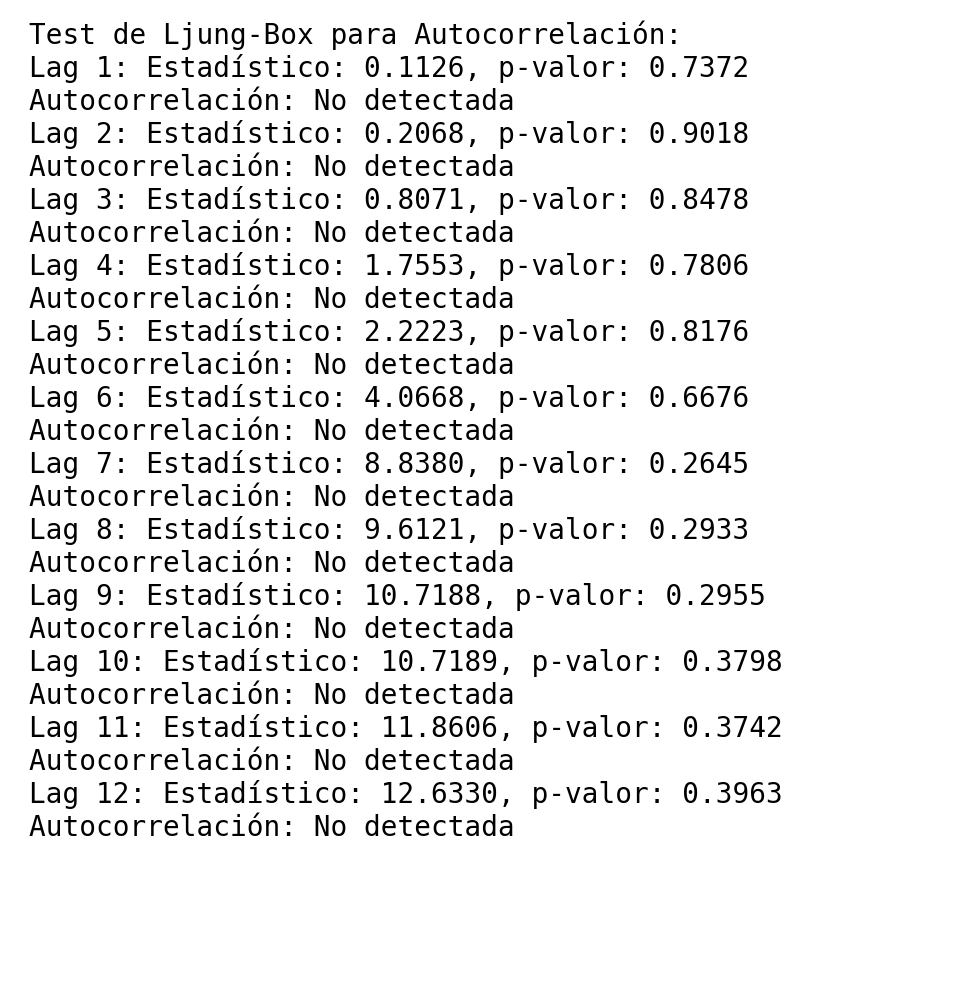

In [47]:
# Suponiendo que ya tienes tu DataFrame lb_test con los resultados
# Construimos una cadena con toda la información que imprimirías normalmente
texto_salida = "Test de Ljung-Box para Autocorrelación:\n"

for i, row in lb_test.iterrows():
    texto_salida += f"Lag {i}: Estadístico: {row['lb_stat']:.4f}, p-valor: {row['lb_pvalue']:.4f}\n"
    texto_salida += f"Autocorrelación: {'Presente' if any(p < 0.05 for p in lb_test['lb_pvalue']) else 'No detectada'}\n"

plt.rc('figure', figsize=(5, 5), dpi=200)
plt.text(0.01, 0.99, texto_salida, {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('LjunBox_capm_02.png')

<Figure size 2400x1200 with 0 Axes>

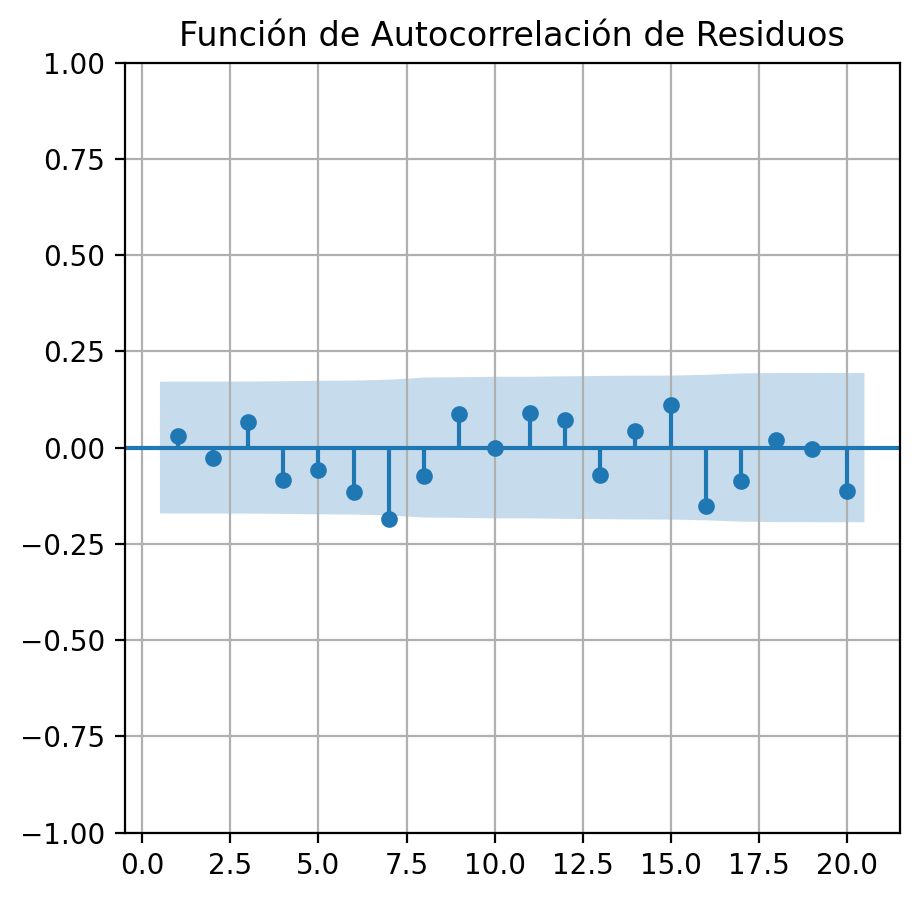

<Figure size 2400x1200 with 0 Axes>

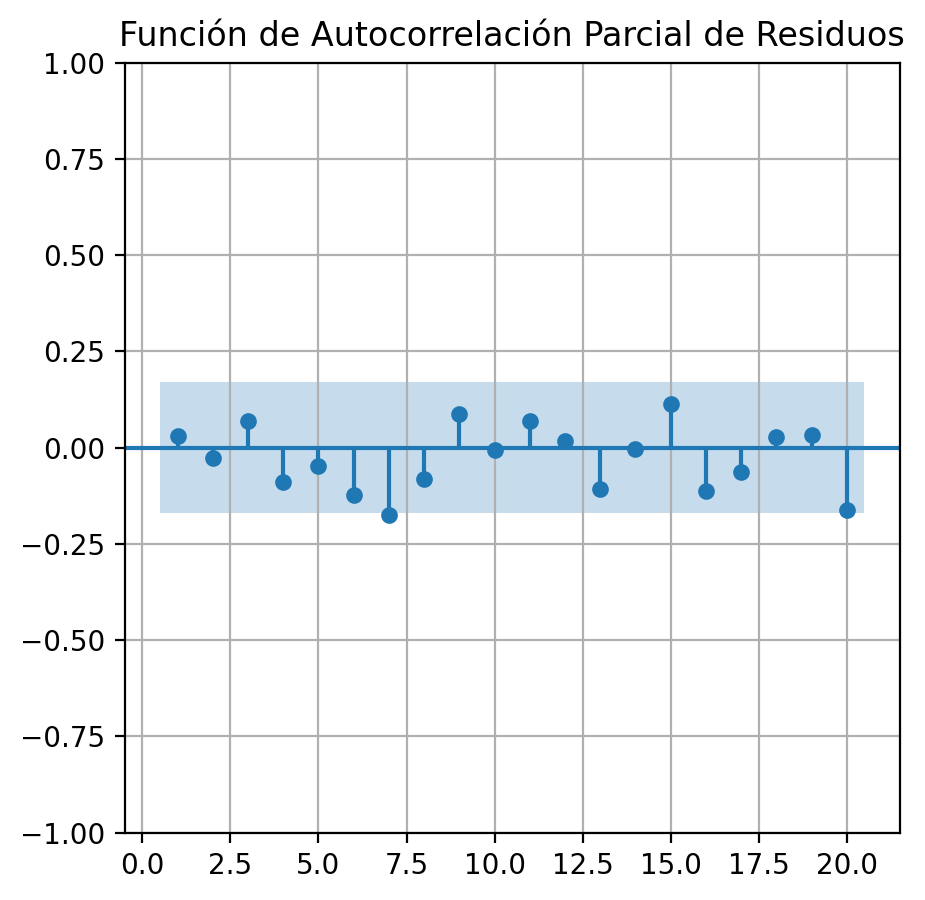

In [48]:
# Función de autocorrelación (ACF)
plt.figure(figsize=(12, 6))
plot_acf(residuos, lags=20, alpha=0.05, zero=False, title='Función de Autocorrelación de Residuos')
plt.grid(True)
plt.savefig('residuos_acf.png') # grabar el grafico
plt.show()

# Función de autocorrelación parcial (PACF)
plt.figure(figsize=(12, 6))
plot_pacf(residuos, lags=20, alpha=0.05, zero=False,title='Función de Autocorrelación Parcial de Residuos')
plt.grid(True)
plt.savefig('residuos_pacf.png') # grabar el grafic
plt.show()


# **SO4: Analisis de Residuos**

In [49]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [50]:
# leer datos
returns = pd.read_csv('returns_VLY.csv')

In [51]:
returns=returns.dropna()

In [52]:
# Estimar la regresión
import statsmodels.api as sm
modelo_capm = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium']", data=returns).fit()
modelo_capm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.550
Model:                                OLS   Adj. R-squared:                  0.546
Method:                     Least Squares   F-statistic:                     157.5
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           4.20e-24
Time:                            11:42:22   Log-Likelihood:                 182.60
No. Observations:                     131   AIC:                            -361.2
Df Residuals:                         129   BIC:                            -355.5
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0008      0.005     -0.153      0.878      -0.011       0.010
returns['Market Premium']     1.1299      0.090     12.549      0.000       0.952       1.308
==============================================================================
Omnibus:                       16.951   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.822
Skew:                          -0.293   Prob(JB):                     7.56e-13
Kurtosis:                       6.144   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Problemas de heterocesticidad y autocorrelacion en los residuos de un modelo de regresion lineal.**

· Solución estimación robusta mediante newey-west

La heterocedasticidad surge cuando la varianza de los errores en un modelo de regresión no es constante, sino que varía según los valores de las variables explicativas o a lo largo del tiempo (en series de tiempo). Esto viola uno de los supuestos fundamentales del modelo de regresión lineal clásico (aquél que asume homocedasticidad, es decir, varianza constante de los errores).

### **Problemas de la heterocedasticidad**

1. Sesgo en la estimación de varianzas

- Aunque la heterocedasticidad no necesariamente sesga los coeficientes estimados por Mínimos Cuadrados Ordinarios (MCO u OLS), sí afecta la estimación de sus varianzas.
- Cuando existe heterocedasticidad, las fórmulas estándar para los errores estándar (las que asumen homocedasticidad) no son válidas.
- Consecuencia: se pueden obtener intervalos de confianza y valores t inadecuados o engañosos, lo que lleva a inferencias erróneas sobre la significancia de los coeficientes.

2. Impacto en pruebas de hipótesis y en la inferencia

- Si no se corrige la heterocedasticidad, las pruebas de hipótesis (como la prueba t para cada coeficiente, o la prueba F conjunta) pueden resultar sesgadas.
- En la práctica, se corre el riesgo de rechazar hipótesis nulas cuando son verdaderas (aumenta la probabilidad de error Tipo I) o de no rechazar hipótesis falsas (aumenta la probabilidad de error Tipo II) si no se ajustan las varianzas correctamente.

### **Corrección de varianzas con matrices de covarianza robustas**

Para tratar el problema de la heterocedasticidad (y eventualmente también autocorrelación), existen ajustes a la matriz de varianzas y covarianzas de los estimadores. Estos ajustes se conocen como estimadores de varianza robustos o “sandwich estimators”. Un caso particular muy utilizado en series de tiempo es la corrección de Newey-West.

**Estimación robusta de Newey-West**

La estimación de Newey-West (o corrección de Newey-West) extiende la idea de las “varianzas robustas” a la presencia simultánea de heterocedasticidad y autocorrelación (correlación serial en los residuos). Es muy común en modelos de series de tiempo porque, además de que la varianza puede no ser constante (heterocedasticidad), también puede haber correlación de los errores en distintos periodos (autocorrelación).

1. Idea básica

- Newey-West ajusta la matriz de varianza y covarianza de los estimadores de OLS para ser “consistente” frente a heterocedasticidad y autocorrelación de orden arbitrario.
- Se basa en estimar la “varianza de largo plazo” (long-run variance) de los residuos, usando ponderaciones decrecientes a medida que aumenta la distancia temporal entre observaciones.

2. Procedimiento

- Se estiman primero los coeficientes por MCO de la forma habitual.
- Se calculan los residuos y, con esos residuos, se construye un estimador de la matriz de varianza-covarianza que incluye correcciones por heterocedasticidad y autocorrelación.
- Este estimador de la matriz de varianza-covarianza se emplea después en lugar de la matriz clásica (que asume homocedasticidad y no autocorrelación) para computar los errores estándar, intervalos de confianza y estadísticas t.

3. Ventaja

- Permite realizar inferencia válida (pruebas de hipótesis, intervalos de confianza) aun cuando existe violación de los supuestos clásicos de homocedasticidad y no autocorrelación.
- No modifica los coeficientes estimados (siguen siendo los de OLS), sino la forma en que calculamos su varianza-covarianza para hacer inferencia.

4. Limitaciones y consideraciones

- Se necesita elegir un número de rezagos (bandwidth o lag truncation parameter) para construir la estimación Newey-West, usualmente basándose en el tamaño de la muestra y la posible extensión de la autocorrelación.
- En muestras pequeñas, la selección de este parámetro es delicada; valores demasiado grandes o demasiado pequeños pueden afectar la calidad de la estimación robusta.

In [53]:
# estiamcion robusta modelo capm newey west
modelo_capm_newey_west = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_capm_newey_west.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.550
Model:                                OLS   Adj. R-squared:                  0.546
Method:                     Least Squares   F-statistic:                     192.3
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           2.45e-27
Time:                            11:42:22   Log-Likelihood:                 182.60
No. Observations:                     131   AIC:                            -361.2
Df Residuals:                         129   BIC:                            -355.5
Df Model:                               1                                         
Covariance Type:                      HAC                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0008      0.005     -0.154      0.878      -0.011       0.010
returns['Market Premium']     1.1299      0.081     13.869      0.000       0.970       1.290
==============================================================================
Omnibus:                       16.951   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.822
Skew:                          -0.293   Prob(JB):                     7.56e-13
Kurtosis:                       6.144   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

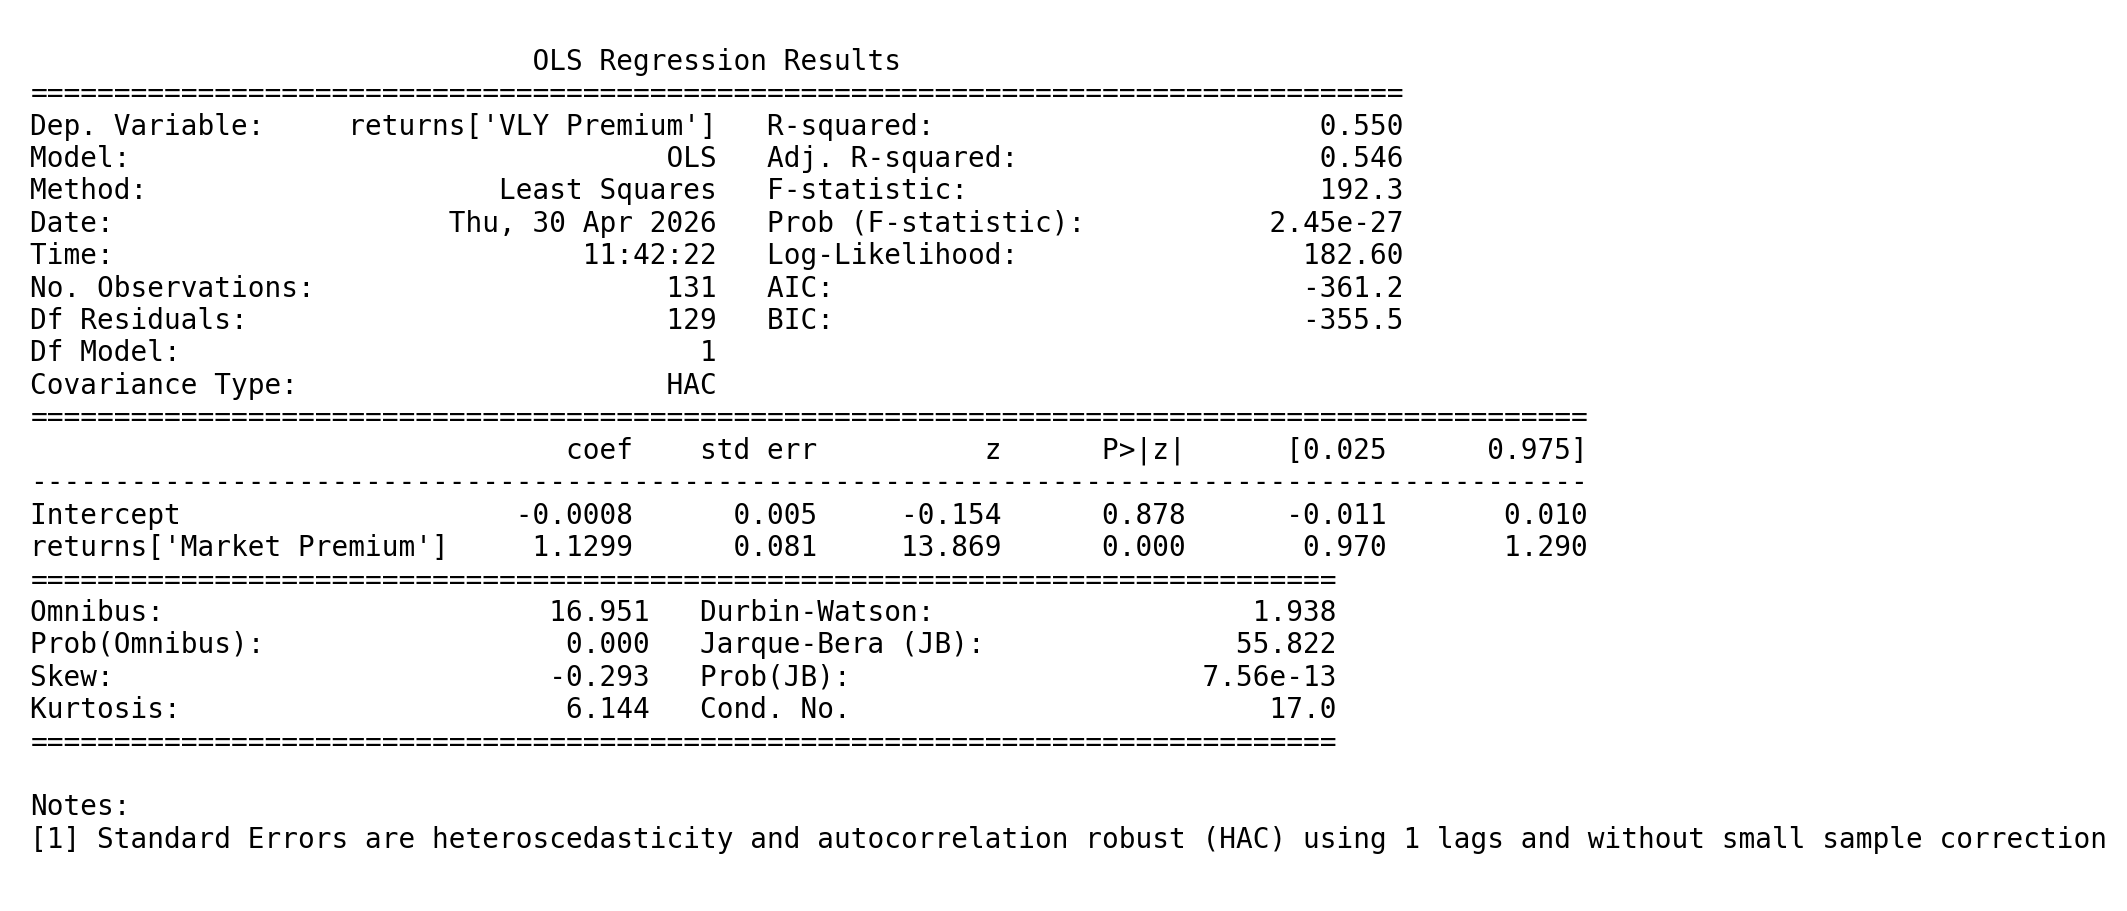

In [54]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.05, modelo_capm_newey_west.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_nw.png')

# **Valores atípicos**

· Modelos de intervención con variables dummies

Al analizar un modelo de regresión, a menudo se detectan valores atípicos (outliers): observaciones que se apartan de forma inusual de la tendencia general de los datos. Estos outliers pueden influir fuertemente en los resultados de la regresión, afectando de manera significativa los coeficientes estimados y, por ende, las conclusiones. Una manera de tratar ciertos valores atípicos (cuando su aparición se explica por un evento concreto, conocido y de carácter temporal) es mediante modelos de intervención que incluyen variables dummy.

### **1. ¿Qué son los valores atípicos y por qué es importante su causa?**

**· Valores atípicos (outliers):** Observaciones que, por alguna razón, son muy diferentes del resto de los datos.

**Importancia de la causa:**
- Los outliers pueden deberse a errores de medición o registro, shocks exógenos (por ejemplo, una crisis económica puntual), cambios normativos, etc
- Identificar la causa ayuda a decidir cómo manejar el outlier. No es lo mismo un error en la toma de datos (que quizás convenga excluir o corregir) que un evento económico relevante (que conviene modelar explícitamente porque podría repetirse bajo circunstancias similares).

### **2. Modelos de intervención con variables dummy**

Cuando se sabe que un valor atípico se debe a un evento específico y temporal, se puede incorporar una variable dummy (o variable indicadora) en el modelo de regresión:

**1. Definición de la dummy**

- Se crea una variable que toma valor 1 para las observaciones afectadas por el evento “anormal” y valor 0 para el resto.
- Este evento puede ocurrir en un único periodo (por ejemplo, un único trimestre) o en un grupo reducido de periodos con efecto diferido.

**2. Incorporación al modelo**

- Se añade la dummy como una variable explicativa adicional:
[ Y_t = \beta_0 + \beta1 X{1t} + \cdots + \betak X{kt} + \gamma D_t + \varepsilon_t ]
donde (D_t) es la dummy que toma valor 1 en el/los periodo(s) del outlier.
- El coeficiente (\gamma) mide la diferencia en la variable dependiente (Y) que se asocia específicamente a ese evento atípico.

**3. Interpretación**

- Si (\gamma) resulta estadísticamente significativo, indica que el evento capturado por la dummy tuvo un impacto puntual (o de corto plazo) en la variable dependiente.
- Si no es significativo, sugiere que el valor atípico no se explica por ese factor particular o que el evento no tuvo una influencia estadísticamente relevante.

**4. Ventaja principal**

- Permite aislar el efecto del outlier mediante la creación de una variable especial.
- Se justifica únicamente cuando se conoce la razón económica o financiera detrás de ese outlier y se considera relevante en la dinámica del modelo.

## **3. Recomendaciones**

**· Conocer la causa real del outlier:**

- Para justificar la incorporación de una dummy de intervención, es fundamental saber por qué ocurrió el valor atípico (evento económico, fenómeno financiero, shock regulatorio, etc.).
- Sin esta justificación, simplemente incluir dummies para “limpiar” la muestra puede llevar a resultados engañosos.

**· Incluir la dummy en el modelo:**

- Se crea una variable que capture el o los periodos atípicos y se la incorpora como regresor.
- Con ello, se aísla el efecto de la observación extrema y se mantiene coherencia en el resto de la muestra.

**·Interpretar la magnitud y significancia del coeficiente:**

- El coeficiente asociado a la dummy ((\gamma)) mide la intensidad del efecto del outlier.
- Permite ver si ese efecto se debe a un factor único y temporal o si puede representar un cambio estructural (en cuyo caso se usaría otro tipo de modelado, por ejemplo, un cambio de régimen o una dummy permanente).

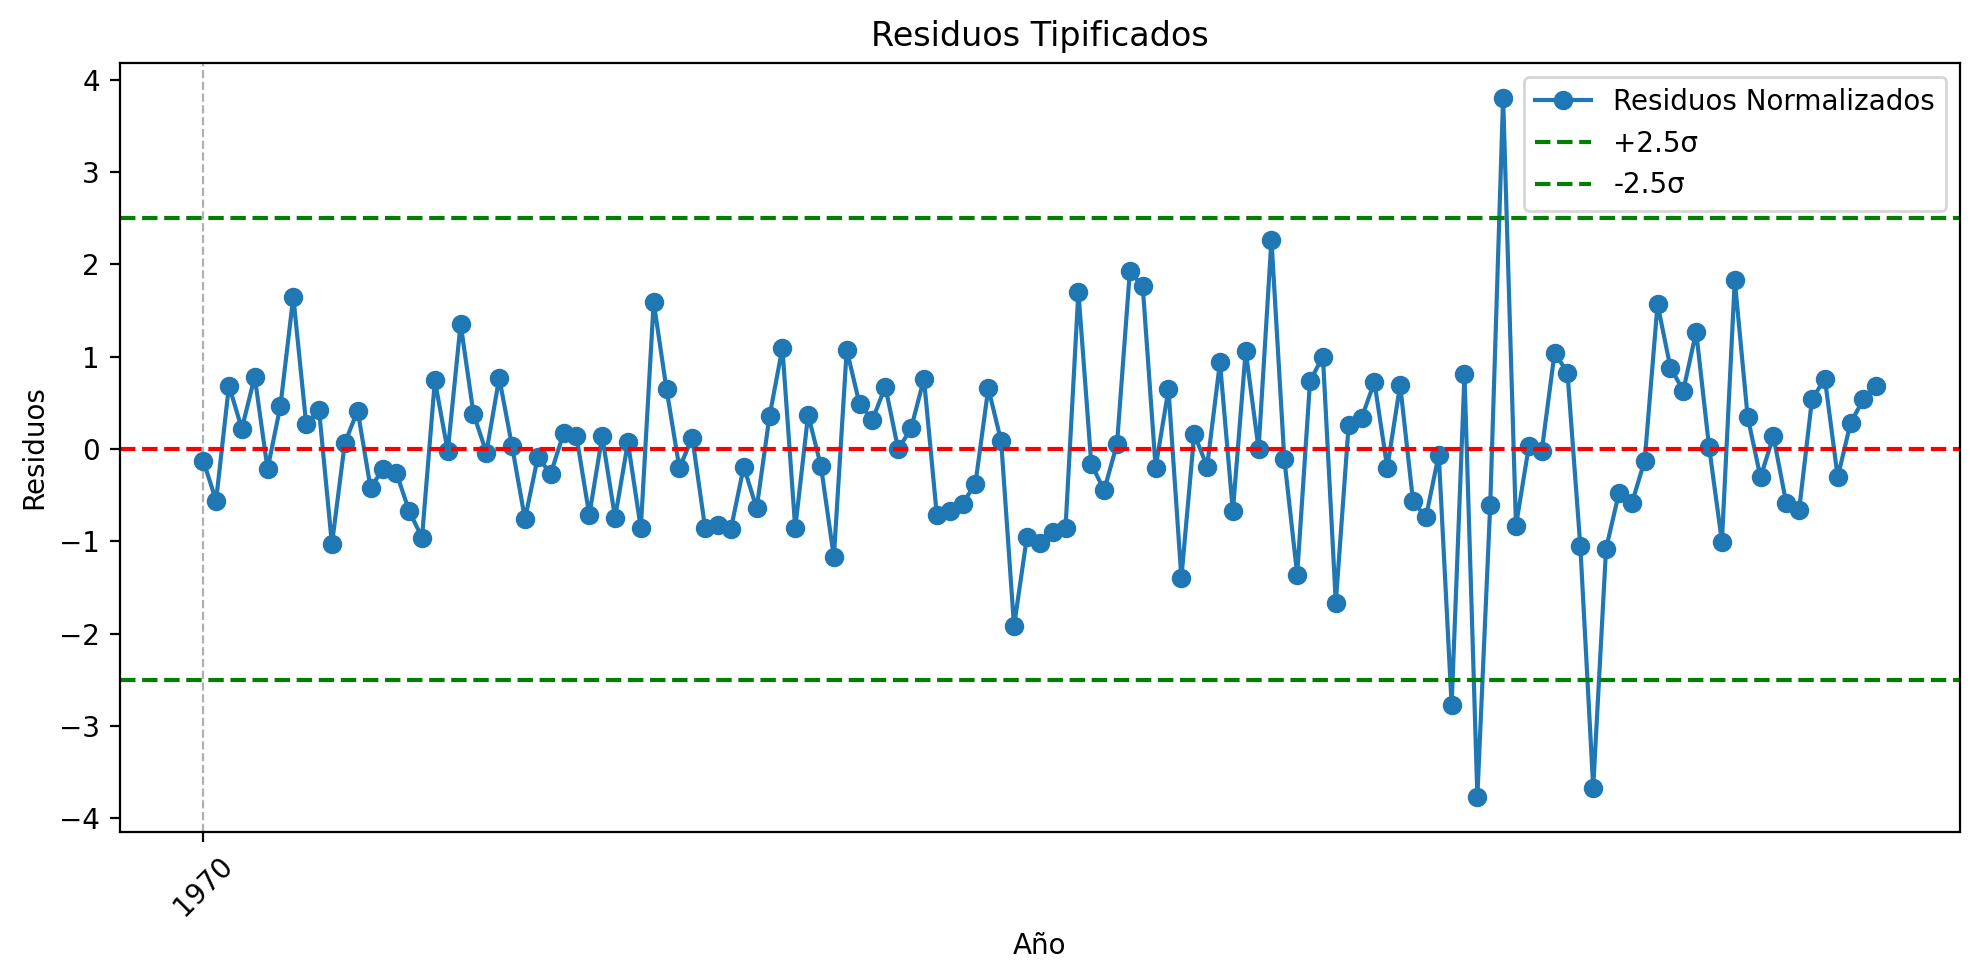

In [55]:
import matplotlib.dates as mdates

# residuos
returns.index=returns['Date']
returns['residuos'] = modelo_capm.resid.values
# Normalización de los residuos
returns['residuos_normalizados'] = (returns['residuos'] - np.mean(returns['residuos'])) / np.std(returns['residuos'])

# Configuración de los ticks y el grid en el inicio de cada año
year_locator = mdates.YearLocator()  # Localizador para cada inicio de año
year_formatter = mdates.DateFormatter('%Y')  # Formateador para mostrar solo el año


plt.figure(figsize=(10, 5))
plt.plot(returns['residuos_normalizados'], marker='o', linestyle='-', label='Residuos Normalizados')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(2.5, color='green', linestyle='--', label='+2.5σ')
plt.axhline(-2.5, color='green', linestyle='--', label='-2.5σ')

# Configurar el eje x
ax = plt.gca()
ax.xaxis.set_major_locator(year_locator)  # Ticks en cada año
ax.xaxis.set_major_formatter(year_formatter)  # Mostrar solo el año
plt.grid(True, which='major', axis='x', linestyle='--')  # Grid en los inicios de año

# Rotar las etiquetas del eje x si  para mayor claridad
plt.xticks(rotation=45)

plt.title('Residuos Tipificados')
plt.xlabel('Año')
plt.ylabel('Residuos')
plt.legend()
plt.tight_layout()  # Ajustar el diseño para evitar recortes
plt.show()

In [56]:
# Mostar los datos que son > o < 2.5σ
# hacer la logica condicioanla  al vez

returns[abs(returns['residuos_normalizados'])> 2.5]['residuos']

,residuos
Date,
2023-03-01,-0.166716
2023-05-01,-0.226105
2023-07-01,0.228390
2024-02-01,-0.220283


##**VALLEY NATIONAL BANCORP ANNOUNCES SECOND QUARTER 2023 EARNINGS**

July 27, 2023

- Net income for the second quarter of 2023 reached $139.1 million
- Net interest mergin declined to 2,94%
- Total deposits increased to 49.6 billion
- Total loans increased to approximately 49,9 billion

In [57]:
# Asegurar que Date es fecha e índice
returns['Date'] = pd.to_datetime(returns['Date'])
returns = returns.set_index('Date').sort_index()

# Crear dummy para la intervención en julio de 2023
returns['intervencion'] = 0
returns.loc[(returns.index.month == 7) & (returns.index.year == 2023), 'intervencion'] = 1

# Comprobar que se ha creado bien
print(returns['intervencion'].value_counts())
print(returns[returns['intervencion'] == 1].index)

# Estimar la regresión con dummy
modelo_capm_newey_west_outlier = sm.OLS.from_formula(
    "returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion']",
    data=returns
).fit(cov_type='HAC', cov_kwds={'maxlags':1})

modelo_capm_newey_west_outlier.summary()

intervencion
0    130
1      1
Name: count, dtype: int64
DatetimeIndex(['2023-07-01'], dtype='datetime64[ns]', name='Date', freq=None)


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.600
Model:                                OLS   Adj. R-squared:                  0.594
Method:                     Least Squares   F-statistic:                     1691.
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           9.10e-93
Time:                            11:42:23   Log-Likelihood:                 190.38
No. Observations:                     131   AIC:                            -374.8
Df Residuals:                         128   BIC:                            -366.1
Df Model:                               2                                         
Covariance Type:                      HAC                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0025      0.005     -0.479      0.632      -0.013       0.008
returns['Market Premium']     1.1041      0.077     14.294      0.000       0.953       1.256
returns['intervencion']       0.2314      0.007     34.931      0.000       0.218       0.244
==============================================================================
Omnibus:                       24.289   Durbin-Watson:                   1.844
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               51.274
Skew:                          -0.765   Prob(JB):                     7.35e-12
Kurtosis:                       5.656   Cond. No.                         17.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

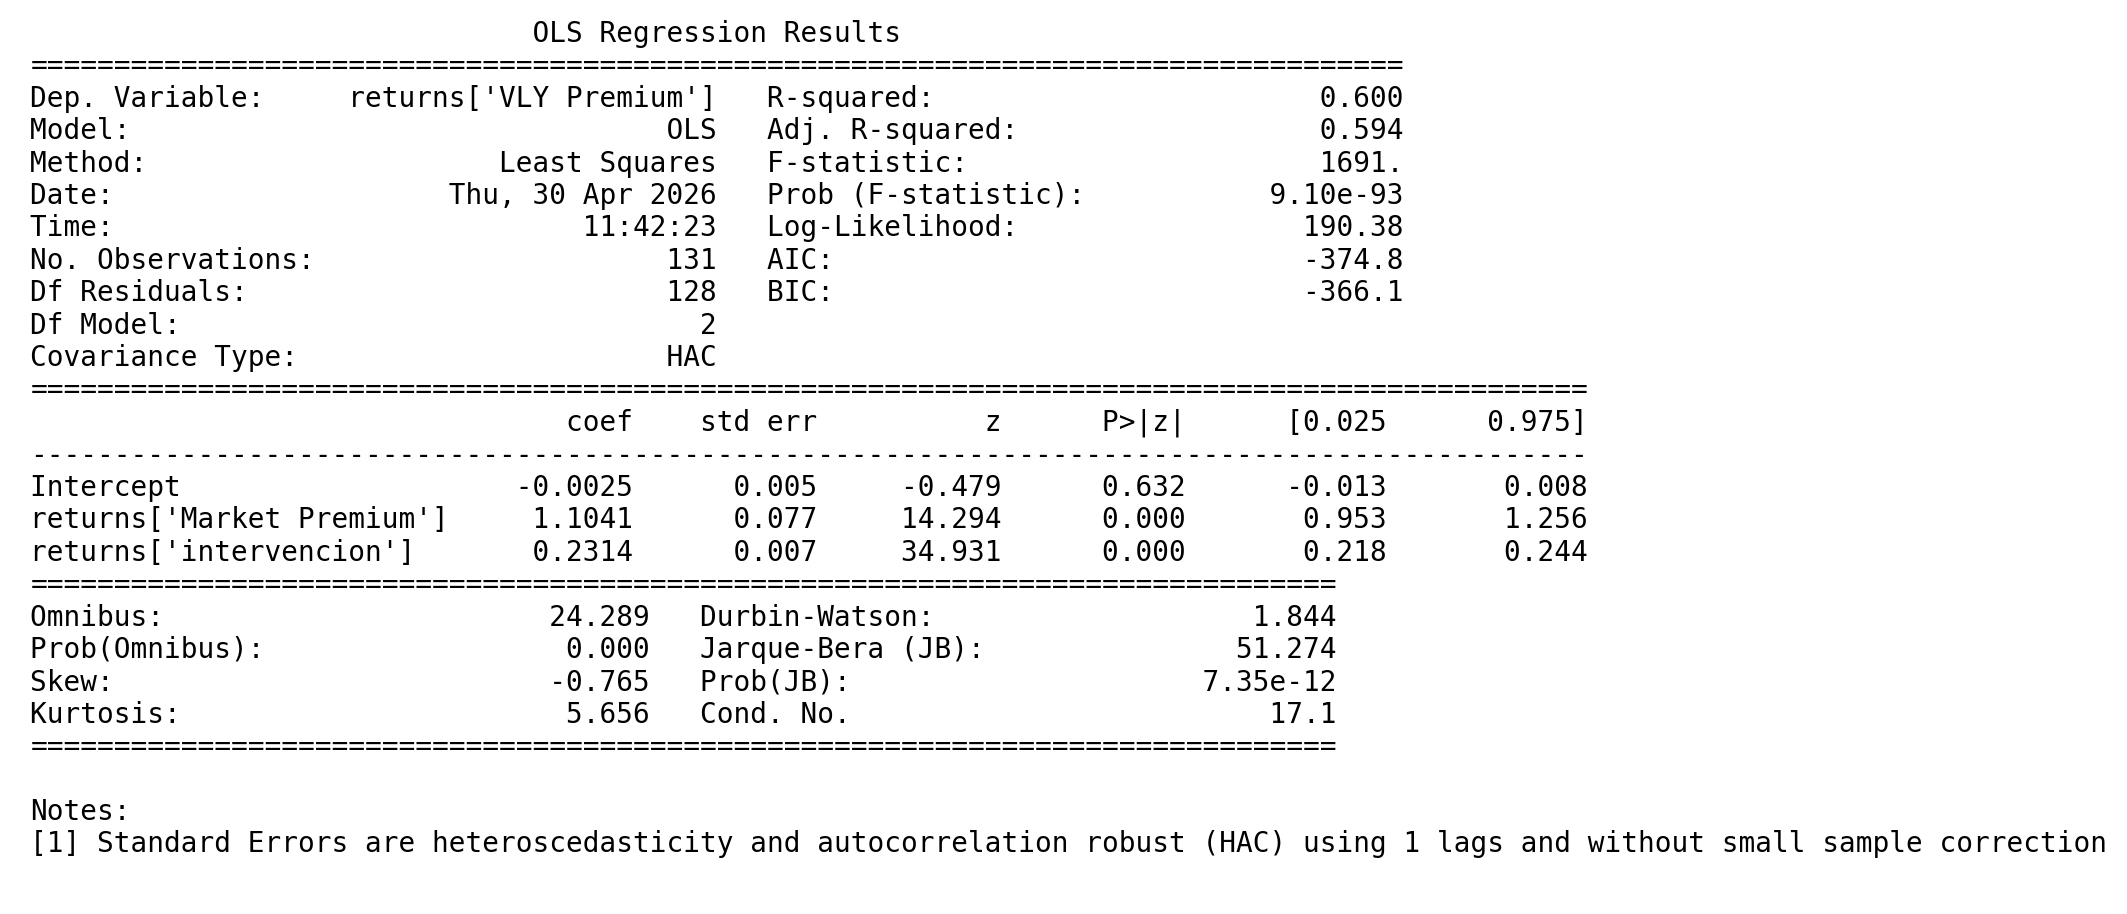

In [58]:
plt.rc('figure', figsize=(9, 5), dpi=200)
plt.text(0.01, 0.05, modelo_capm_newey_west_outlier.summary(), {'fontsize': 10}, fontproperties = 'monospace')
plt.axis('off')
plt.tight_layout()
plt.savefig('regresion_capm_nw_outlier.png')

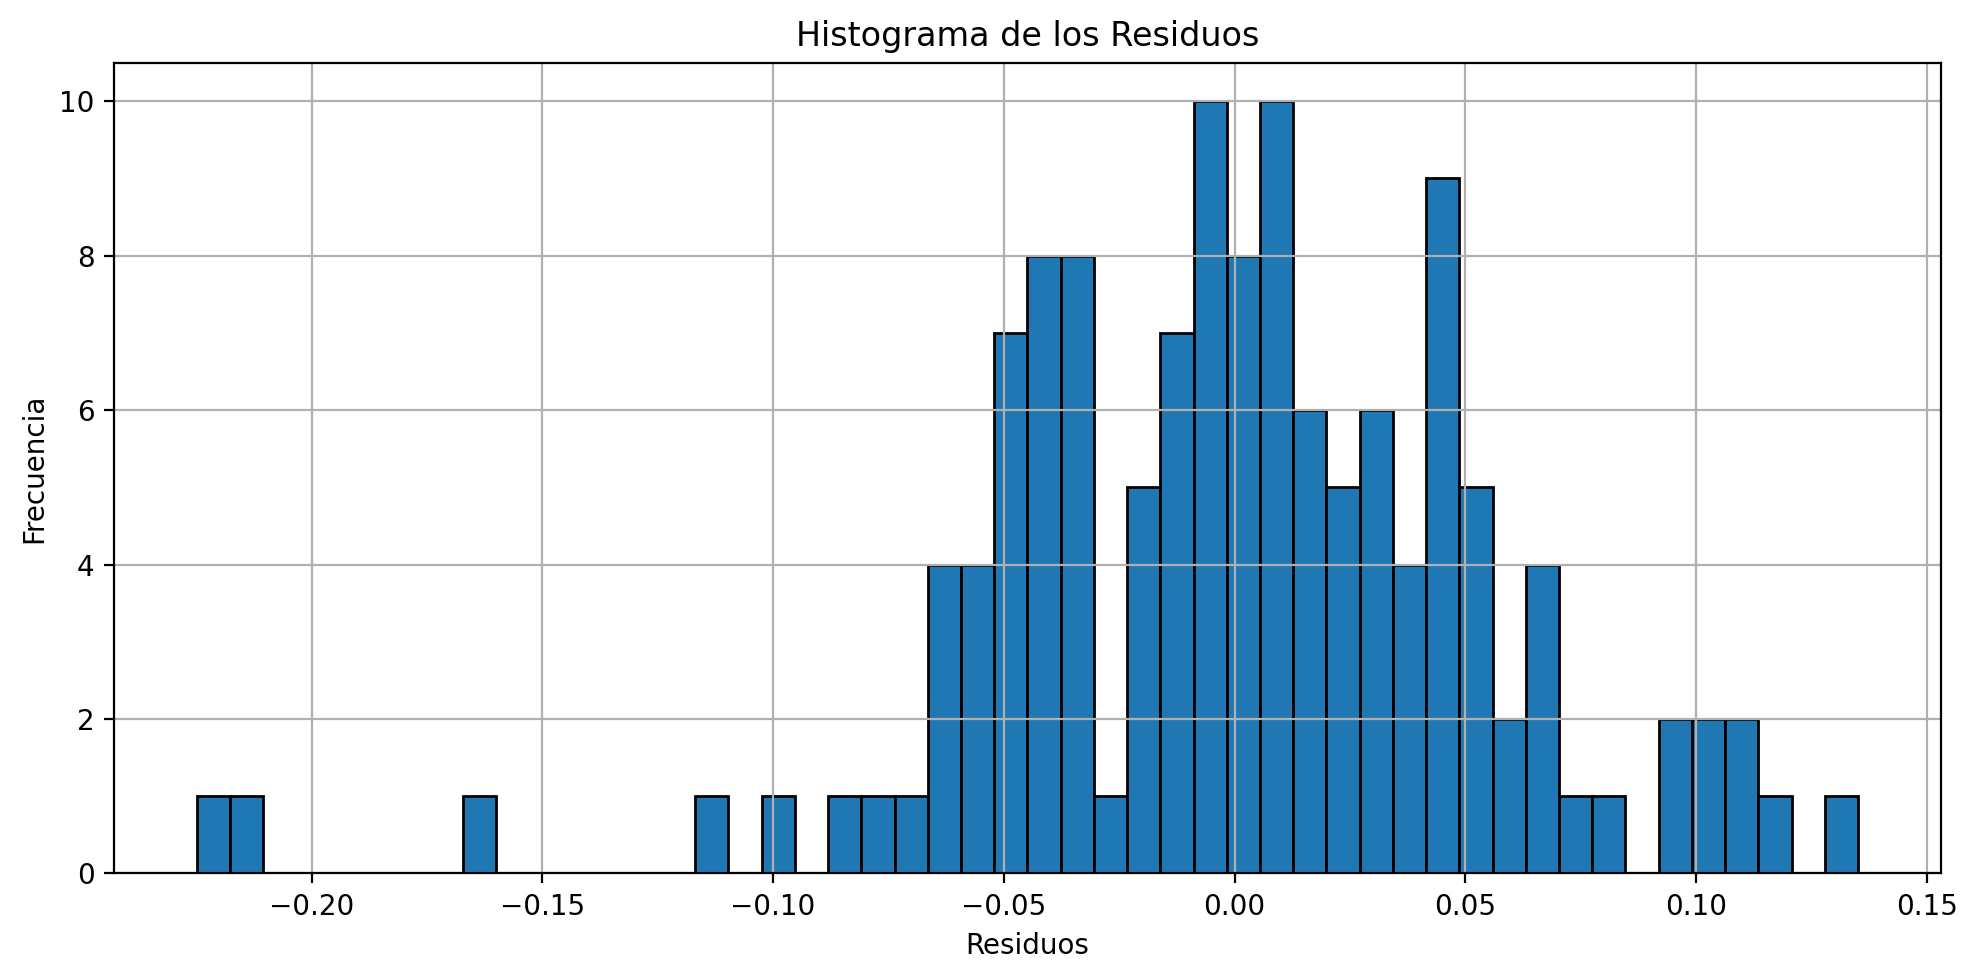

In [59]:
# Generar los residuos del modelo con dummy
returns['residuos_outlier'] = modelo_capm_newey_west_outlier.resid.values

# histograma de los residuos
plt.figure(figsize=(10, 5))
plt.hist(returns['residuos_outlier'], bins=50, edgecolor='black')
plt.title('Histograma de los Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 2000x1200 with 0 Axes>

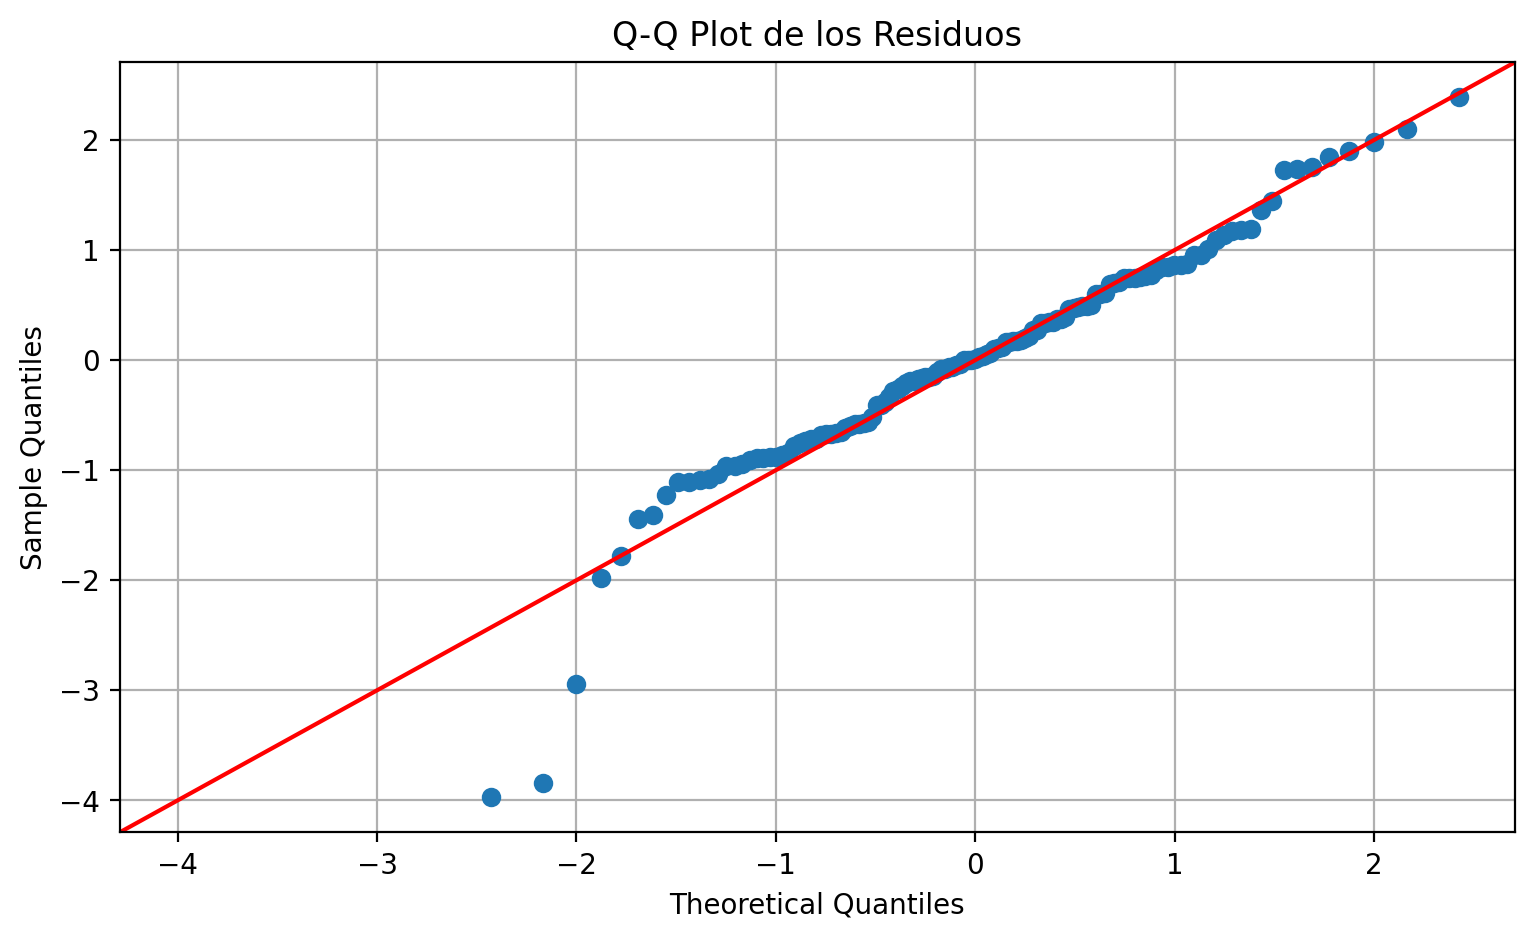

In [60]:
# Gráfico Q-Q Plot
import scipy.stats as stats
plt.figure(figsize=(10, 6))
fig = sm.qqplot(returns['residuos_outlier'], stats.norm, line='45', fit=True)
plt.title('Q-Q Plot de los Residuos')
plt.grid(True)
plt.show()

In [61]:
# Test de Jarque-Bera para normalidad
jb_test = sm.stats.jarque_bera(returns['residuos_outlier'])
print(f"Test de Jarque-Bera:")
print(f"Estadístico: {jb_test[0]:.4f}")
print(f"p-valor: {jb_test[1]:.4f}")
print(f"Normalidad: {'Se rechaza' if jb_test[1] < 0.05 else 'No se rechaza'}")
print("\n")

Test de Jarque-Bera:
Estadístico: 51.2738
p-valor: 0.0000
Normalidad: Se rechaza




In [62]:
# save data como dataframe
returns.to_csv('returns_capm.csv')

# **SO5: Cambio Estructural**

In [63]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [64]:
# quitar warnings
import warnings
warnings.filterwarnings("ignore")

In [65]:
# leer datos
returns = pd.read_csv('returns_VLY.csv')
returns['Date'] = pd.to_datetime(returns['Date'])
returns.set_index('Date', inplace=True)
returns.head()

,VLY,R2000,Rentabilidad_VLY,Rentabilidad_R2000,Mkt-RF,SMB,HML,RF,Market Premium,VLY Premium
Date,,,,,,,,,,
2015-01-01,5.577916,1165.390015,NaN,NaN,-0.0310,-0.0059,-0.0345,0.0,NaN,NaN
2015-02-01,5.897358,1233.369995,0.055689,0.056694,0.0613,0.0061,-0.0179,0.0,0.056694,0.055689
2015-03-01,5.799068,1252.770020,-0.016807,0.015607,-0.0111,0.0305,-0.0038,0.0,0.015607,-0.016807
2015-04-01,5.860570,1220.130005,0.010550,-0.026400,0.0059,-0.0299,0.0180,0.0,-0.026400,0.010550
2015-05-01,6.078091,1246.530029,0.036444,0.021406,0.0137,0.0095,-0.0111,0.0,0.021406,0.036444


## **Modelo Correcto: Newey-West y atipicos**

In [66]:
# Estimar la regresión
import statsmodels.api as sm

# Crear dummy para la intervención el 2023-07-01
returns['intervencion'] = 0
returns.loc[returns.index == '2023-07-01', 'intervencion'] = 1

returns['2_intervencion'] = 0
returns.loc[returns.index == '2023-05-01', '2_intervencion'] = 1

In [67]:
# Estimar la regresión con dummy
modelo_capm_newey_west_outlier = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['2_intervencion']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_capm_newey_west_outlier.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.649
Model:                                OLS   Adj. R-squared:                  0.640
Method:                     Least Squares   F-statistic:                     110.2
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           1.81e-28
Time:                            11:42:24   Log-Likelihood:                 198.87
No. Observations:                     131   AIC:                            -389.7
Df Residuals:                         127   BIC:                            -378.2
Df Model:                               3                                         
Covariance Type:                      HAC                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0007      0.005     -0.141      0.888      -0.010       0.009
returns['Market Premium']     1.0949      0.077     14.238      0.000       0.944       1.246
returns['intervencion']       0.2302      0.006     35.444      0.000       0.217       0.243
returns['2_intervencion']    -0.2267      0.005    -45.199      0.000      -0.237      -0.217
==============================================================================
Omnibus:                       13.497   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               24.196
Skew:                          -0.448   Prob(JB):                     5.57e-06
Kurtosis:                       4.906   Cond. No.                         17.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

### **Constante y pendiente**


In [68]:
# Constante y pendiente
# Cambio estructural del COVID: returns['covid']* returns['Market Premium']
returns['covid'] = 0
returns.loc[returns.index >= '2020-03-01', 'covid'] = 1

# Estimar la regresión con dummy
modelo_capm_newey_west_outlier_covid= sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['2_intervencion']+ returns['covid']* returns['Market Premium']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_capm_newey_west_outlier_covid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.649
Model:                                OLS   Adj. R-squared:                  0.635
Method:                     Least Squares   F-statistic:                     61.96
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           9.23e-29
Time:                            11:42:24   Log-Likelihood:                 198.92
No. Observations:                     131   AIC:                            -385.8
Df Residuals:                         125   BIC:                            -368.6
Df Model:                               5                                         
Covariance Type:                      HAC                                         
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -0.0005      0.005     -0.098      0.922      -0.011       0.010
returns['Market Premium']                      1.1334      0.101     11.202      0.000       0.935       1.332
returns['intervencion']                        0.2313      0.010     22.890      0.000       0.211       0.251
returns['2_intervencion']                     -0.2268      0.008    -28.058      0.000      -0.243      -0.211
returns['covid']                              -0.0004      0.010     -0.037      0.970      -0.019       0.019
returns['covid']:returns['Market Premium']    -0.0554      0.144     -0.384      0.701      -0.338       0.227
==============================================================================
Omnibus:                       13.221   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               23.722
Skew:                          -0.436   Prob(JB):                     7.06e-06
Kurtosis:                       4.894   Cond. No.                         53.8
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

## **Test F, conjunto:**

**anova_lm:** (statsmodels) realiza una comparación tipo ANOVA entre modelos lineales. Resumen breve:

**Qué hace:** compara suma de cuadrados residuales entre modelos para evaluar si parámetros adicionales mejoran el ajuste.
**Cuándo usarlo:** modelos lineales (OLS) anidados — mismo variable dependiente y mismas observaciones. El orden importa: primero el modelo reducido, luego el completo.

**Salida típica (columnas):** df_resid: grados de libertad residuales del modelo.

ssr / ss_diff: suma de cuadrados residuales y su diferencia entre modelos.

df_diff: diferencia en grados de libertad.

F y Pr(>F): estadístico F y p-valor para probar si la mejora del modelo completo es significativa.

Interpretación: p pequeño => rechazar la hipótesis nula de que el modelo reducido es suficiente (los coeficientes añadidos aportan mejora significativa).

In [69]:
# test F para verificar que la pendiente y la constante son iguales antes y después del COVID
from statsmodels.stats.anova import anova_lm
anova_lm(modelo_capm_newey_west_outlier, modelo_capm_newey_west_outlier_covid)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,127.0,0.368294,0.0,NaN,NaN,NaN
1,125.0,0.367992,2.0,0.000302,0.051228,0.950082


## **Interpretación**

Resultado e interpretación breve:

**Tabla ANOVA:** df_resid 127 → 125, ss_diff = 0.000302, F = 0.051228, Pr(>F) = 0.950082.

**Interpretación:** El p-valor es 0.9501 (> 0.05), por lo que no se rechaza la hipótesis nula. Esto indica que las variables añadidas, la dummy COVID y su interacción con Market Premium, no mejoran significativamente el ajuste del modelo según el test F de anova_lm.

Por tanto, no hay evidencia estadística suficiente de un cambio estructural significativo asociado al COVID en la relación entre la prima de rentabilidad de VLY y la prima de mercado dentro de esta especificación.

**Nota:** anova_lm utiliza la suma de cuadrados residuales estándar y no incorpora errores robustos HAC. Por ello, este contraste debe interpretarse como una referencia complementaria al análisis principal realizado con errores robustos.

## **Test F, conjunto con Newey-West**

In [70]:
# Ejecutar un Wald test conjunto usando la covarianza robusta del modelo completo
restr = "returns['covid'] = 0, returns['covid']:returns['Market Premium'] = 0"
wald_res = modelo_capm_newey_west_outlier_covid.wald_test(restr, cov_p=modelo_capm_newey_west_outlier_covid.cov_params())
wald_res

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[0.15147282]], p-value=0.9270605371933338, df_denom=2>

## **Pendiente**

In [71]:
# pendiente
# Estimar la regresión con dummy returns['covid'] : returns['Market Premium']
modelo_capm_newey_west_outlier_covid= sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['2_intervencion']+ returns['covid']: returns['Market Premium']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_capm_newey_west_outlier_covid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.649
Model:                                OLS   Adj. R-squared:                  0.638
Method:                     Least Squares   F-statistic:                     82.60
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           1.30e-29
Time:                            11:42:24   Log-Likelihood:                 198.92
No. Observations:                     131   AIC:                            -387.8
Df Residuals:                         126   BIC:                            -373.5
Df Model:                               4                                         
Covariance Type:                      HAC                                         
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -0.0007      0.005     -0.144      0.886      -0.010       0.009
returns['Market Premium']                      1.1336      0.100     11.301      0.000       0.937       1.330
returns['intervencion']                        0.2311      0.008     29.958      0.000       0.216       0.246
returns['2_intervencion']                     -0.2270      0.005    -45.350      0.000      -0.237      -0.217
returns['covid']:returns['Market Premium']    -0.0558      0.144     -0.388      0.698      -0.337       0.226
==============================================================================
Omnibus:                       13.337   Durbin-Watson:                   1.798
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               23.957
Skew:                          -0.440   Prob(JB):                     6.28e-06
Kurtosis:                       4.901   Cond. No.                         46.2
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

## **Constante**

In [72]:
# Constante returns['covid']
# Estimar la regresión con dummy returns['covid']
modelo_capm_newey_west_outlier_covid= sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion']+ returns['2_intervencion']+ returns['covid']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_capm_newey_west_outlier_covid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.649
Model:                                OLS   Adj. R-squared:                  0.638
Method:                     Least Squares   F-statistic:                     73.39
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           1.60e-27
Time:                            11:42:24   Log-Likelihood:                 198.87
No. Observations:                     131   AIC:                            -387.7
Df Residuals:                         126   BIC:                            -373.4
Df Model:                               4                                         
Covariance Type:                      HAC                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.0004      0.005     -0.078      0.938      -0.011       0.010
returns['Market Premium']     1.0949      0.077     14.263      0.000       0.944       1.245
returns['intervencion']       0.2304      0.009     24.565      0.000       0.212       0.249
returns['2_intervencion']    -0.2265      0.008    -28.054      0.000      -0.242      -0.211
returns['covid']             -0.0006      0.010     -0.058      0.954      -0.019       0.018
==============================================================================
Omnibus:                       13.315   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               23.830
Skew:                          -0.441   Prob(JB):                     6.69e-06
Kurtosis:                       4.894   Cond. No.                         19.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

##**Valley National Bancorp y el riesgo CRE**

En marzo de 2024, S&P Global revisó a negativa la perspectiva de Valley National Bancorp por su exposición al commercial real estate. Este evento puede interpretarse como un posible cambio estructural en la percepción de riesgo del banco, por lo que se modeliza mediante una dummy que toma valor 1 desde 2024-04-01 en adelante.

In [73]:
# Constante y pendiente
# Cambio estructural por riesgo CRE
returns['cre_riesgo'] = 0
returns.loc[returns.index == '2024-04-01', 'cre_riesgo'] = 1

In [74]:
# Estimar la regresión con dummy
modelo_capm_newey_west_outlier_cre = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['2_intervencion'] + returns['cre_riesgo'] * returns['Market Premium']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_capm_newey_west_outlier_cre.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.650
Model:                                OLS   Adj. R-squared:                  0.639
Method:                     Least Squares   F-statistic:                     103.6
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           2.44e-27
Time:                            11:42:24   Log-Likelihood:                 199.05
No. Observations:                     131   AIC:                            -388.1
Df Residuals:                         126   BIC:                            -373.7
Df Model:                               4                                         
Covariance Type:                      HAC                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                          -0.0004      0.005     -0.085      0.932      -0.010       0.009
returns['Market Premium']                           1.0889      0.078     13.967      0.000       0.936       1.242
returns['intervencion']                             0.2302      0.006     35.420      0.000       0.217       0.243
returns['2_intervencion']                          -0.2271      0.005    -45.016      0.000      -0.237      -0.217
returns['cre_riesgo']                              -0.0321      0.008     -4.131      0.000      -0.047      -0.017
returns['cre_riesgo']:returns['Market Premium']     0.0025      0.001      4.131      0.000       0.001       0.004
==============================================================================
Omnibus:                       13.937   Durbin-Watson:                   1.825
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               25.128
Skew:                          -0.463   Prob(JB):                     3.49e-06
Kurtosis:                       4.936   Cond. No.                     6.88e+17
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
[2] The smallest eigenvalue is 2.77e-34. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [75]:
# Ejecutar un Wald test conjunto usando la covarianza robusta del modelo completo
restr = "returns['cre_riesgo'] = 0, returns['cre_riesgo']:returns['Market Premium'] = 0"
wald_res = modelo_capm_newey_west_outlier_cre.wald_test(restr, cov_p=modelo_capm_newey_west_outlier_cre.cov_params())
wald_res

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=[[17.0634921]], p-value=3.6150614130435e-05, df_denom=1>

# **S06:**

# **Modelo de 3 Factores de Fama y French**

**El modelo de 3 factores de Fama y French es un modelo de valoración de activos que busca explicar los rendimientos de una acción o cartera de acciones en función de tres factores:**

1. **Rendimiento del mercado:** Representa el rendimiento del mercado en su conjunto, generalmente medido por un índice de referencia como el S&P 500.
2. **Tamaño:** Este factor se refiere a la capitalización de mercado de las empresas. Se basa en la premisa de que las acciones de empresas más pequeñas tienden a tener rendimientos más altos que las acciones de empresas más grandes.
3. **Valor:** Este factor se refiere a la relación entre el valor contable y el precio de mercado de una acción. Se basa en la premisa de que las acciones que se consideran "baratas" (con un alto valor contable en relación con su precio) tienden a tener rendimientos más altos que las acciones que se consideran "caras" (con un bajo valor contable en relación con su precio).

### **Fórmula del modelo de 3 factores de Fama y French**

El modelo se expresa matemáticamente de la siguiente manera:

**Ri−Rf= α + βm(Rm−Rf)+ βs· SMB+ βv · HML+ ϵi**


Donde:
- Ri: es el rendimiento de la acción o cartera.
- Rf: es la tasa libre de riesgo.
- α: es el rendimiento anormal o "alfa" de la acción o cartera.
- βm: es la sensibilidad del rendimiento de la acción o cartera al rendimiento del mercado.
- Rm: es el rendimiento del mercado.
- SMB (Small Minus Big): es el rendimiento de las acciones de empresas pequeñas menos el rendimiento de las acciones de empresas grandes.
- HML (High Minus Low): es el rendimiento de las acciones de valor menos el rendimiento de las acciones de crecimiento.
- βs y βv: son las sensibilidades de la acción o cartera a los factores de tamaño y valor, respectivamente.
- ϵi: es el término de error, que representa la parte del rendimiento que no se puede explicar por los factores del modelo.
- Ri − Rf: es el exceso de rendimiento de la acción o cartera sobre la tasa libre de riesgo.
- Rm − Rf: es el exceso de rendimiento del mercado sobre la tasa libre de riesgo.
- SMB y HML: son los factores de tamaño y valor, respectivamente, que se utilizan para capturar el efecto de estos dos factores en los rendimientos de las acciones.

## **Interpretación de los factores**

- βm: Un valor positivo indica que la acción o cartera tiende a moverse en la misma dirección que el mercado, mientras que un valor negativo indica que se mueve en la dirección opuesta.
- βs: Un valor positivo indica que la acción o cartera tiende a tener un rendimiento superior en comparación con las acciones de empresas grandes, mientras que un valor negativo indica lo contrario.
- βv: Un valor positivo indica que la acción o cartera tiende a tener un rendimiento superior en comparación con las acciones de crecimiento, mientras que un valor negativo indica lo contrario.
- α: Un valor positivo indica que la acción o cartera ha tenido un rendimiento superior al esperado según el modelo, mientras que un valor negativo indica lo contrario.
- ϵi: Representa la parte del rendimiento que no se puede explicar por los factores del modelo y puede ser atribuida a eventos específicos de la empresa o al ruido del mercado.

In [76]:
# librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [77]:
# quitar warnings
import warnings
warnings.filterwarnings("ignore")

In [78]:
# leer datos
returns = pd.read_csv('returns_VLY.csv')

### **Modelo Correcto: Newey-West + Cambio escrtutural**

In [79]:
# Estimar la regresión
import statsmodels.api as sm

# indexar por fecha
returns['Date'] = pd.to_datetime(returns['Date'])
returns.set_index('Date', inplace=True)

# Dummies para observaciones atípicas
returns['intervencion'] = 0
returns.loc[returns.index == '2023-07-01', 'intervencion'] = 1

returns['2_intervencion'] = 0
returns.loc[returns.index == '2023-05-01', '2_intervencion'] = 1

returns['cre_riesgo'] = 0
returns.loc[returns.index == '2024-04-01', 'cre_riesgo'] = 1

## **Constante y pendiente**

In [80]:
# Constante y pendiente
# Cambio estructural por riesgo CRE: returns['cre_riesgo']* returns['Market Premium']
returns['cre_riesgo'] = 0
returns.loc[returns.index >= '2024-04-01', 'cre_riesgo'] = 1

# Estimar la regresión con dummy
modelo_ff3_cre = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['SMB'] + returns['HML'] + returns['intervencion'] + returns['2_intervencion'] + returns['cre_riesgo']* returns['Market Premium']", data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_ff3_cre.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.766
Model:                                OLS   Adj. R-squared:                  0.753
Method:                     Least Squares   F-statistic:                     42.08
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           1.41e-27
Time:                            11:42:24   Log-Likelihood:                 225.58
No. Observations:                     131   AIC:                            -435.2
Df Residuals:                         123   BIC:                            -412.2
Df Model:                               7                                         
Covariance Type:                      HAC                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                          -0.0023      0.004     -0.541      0.589      -0.011       0.006
returns['Market Premium']                           0.9455      0.116      8.168      0.000       0.719       1.172
returns['SMB']                                      0.0546      0.189      0.290      0.772      -0.315       0.424
returns['HML']                                      0.8214      0.125      6.551      0.000       0.576       1.067
returns['intervencion']                             0.2054      0.008     26.782      0.000       0.190       0.220
returns['2_intervencion']                          -0.1642      0.012    -13.184      0.000      -0.189      -0.140
returns['cre_riesgo']                               0.0161      0.009      1.750      0.080      -0.002       0.034
returns['cre_riesgo']:returns['Market Premium']     0.3311      0.167      1.982      0.047       0.004       0.659
==============================================================================
Omnibus:                        8.373   Durbin-Watson:                   1.887
Prob(Omnibus):                  0.015   Jarque-Bera (JB):               13.889
Skew:                          -0.240   Prob(JB):                     0.000964
Kurtosis:                       4.521   Cond. No.                         55.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

# **Modelo de Fama French**

##**¿Qué es SMB?**

**SMB (Small Minus Big)** mide el exceso de rentabilidad de las acciones de pequeña capitalización frente a las de gran capitalización. Es uno de los factores originales del modelo de Fama-French 3 factores.

- Si **SMB sube** → las small caps lo hacen mejor que las big caps.
- Si **SMB baja** → las big caps lo hacen mejor que las small caps.

##**Si el coeficiente de SMB fuera positivo y significativo**

**Ejemplo: SMB = +0.5, p-valor < 0.05**

- **Interpretación:** VLY se comporta como una acción de pequeña capitalización.
- **Explicación:** Sus rendimientos tienden a aumentar cuando las small caps superan a las big caps.
- **Conclusión:** VLY estaría expuesta positivamente al efecto tamaño → tiene un perfil similar a empresas pequeñas.

##**Si el coeficiente de SMB fuera negativo y significativo**

**Ejemplo: SMB = -0.5, p-valor < 0.05**

- **Interpretación:** VLY se comporta como una acción de gran capitalización.
- **Explicación:** Sus rendimientos tienden a aumentar cuando las big caps superan a las small caps.
- **Conclusión:** VLY tendría una exposición negativa al efecto tamaño, lo que indicaría que su comportamiento se asemeja más al de empresas grandes (a pesar de que, en capitalización, podría ser una small cap en términos absolutos).

##**¿Qué es HML?**

**HML (High Minus Low)** mide el rendimiento diferencial entre:

- **High:** acciones con alto book-to-market (B/M) → acciones de valor.
- **Low:** acciones con bajo book-to-market → acciones de crecimiento o "glamour".

Cuando **HML** sube, las acciones de valor superan a las de crecimiento.

Cuando **HML** baja, las acciones de crecimiento superan a las de valor.

##**Si el coeficiente de HML fuera positivo y significativo**

**Ejemplo: HML = +0.6, p-valor < 0.05**

- **Interpretación:** VLY se comporta como una acción de valor.
- **Explicación:** Su rentabilidad tiende a subir cuando las acciones de valor tienen un mejor desempeño que las de crecimiento.
- **Conclusión:** VLY tiene exposición positiva al factor valor, es decir, su perfil de riesgo-rendimiento es similar al de empresas con múltiplos bajos (alto B/M, típicamente con precios bajos en relación al valor contable).


##**Si el coeficiente de HML fuera negativo y significativo**

**Ejemplo: HML = -0.6, p-valor < 0.05**

- **Interpretación:** VLY se comporta como una acción de crecimiento o "glamour".
- **Explicación:** Su rentabilidad mejora cuando las acciones de crecimiento superan a las de valor.
- **Conclusión:** VLY muestra exposición negativa al factor valor, alineándose con empresas que cotizan con múltiplos altos (bajo B/M), típicamente por su perfil de crecimiento esperado alto.

##**Si HML no fuera significativo**

- No puedes afirmar si VLY se comporta como una acción de valor o crecimiento.
- El modelo no encuentra una relación clara entre los retornos de VLY y el efecto valor/crecimiento.


## **Resumen interpretativo**

| Signo de HML | Significancia | Interpretación | Perfil del activo |
|---|---|---|---|
| Positivo | Significativo | Responde bien cuando ganan las acciones de valor | "valor" |
| Negativo | Significativo | Responde bien cuando ganan las acciones de crecimiento | "glamour" |
| Cualquier signo | No significativo | No hay evidencia clara de exposición | No concluyente |

In [81]:
# en rerurne tema los factores
# mostar las columnas:
returns.columns

Index(['VLY', 'R2000', 'Rentabilidad_VLY', 'Rentabilidad_R2000', 'Mkt-RF',
       'SMB', 'HML', 'RF', 'Market Premium', 'VLY Premium', 'intervencion',
       '2_intervencion', 'cre_riesgo'],
      dtype='object')

In [82]:
modelo_3FF = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['2_intervencion'] + returns['SMB'] + returns['HML'] + returns['cre_riesgo'] + returns['cre_riesgo']:returns['Market Premium']",data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_3FF.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.766
Model:                                OLS   Adj. R-squared:                  0.753
Method:                     Least Squares   F-statistic:                     42.08
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           1.41e-27
Time:                            11:42:24   Log-Likelihood:                 225.58
No. Observations:                     131   AIC:                            -435.2
Df Residuals:                         123   BIC:                            -412.2
Df Model:                               7                                         
Covariance Type:                      HAC                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                          -0.0023      0.004     -0.541      0.589      -0.011       0.006
returns['Market Premium']                           0.9455      0.116      8.168      0.000       0.719       1.172
returns['intervencion']                             0.2054      0.008     26.782      0.000       0.190       0.220
returns['2_intervencion']                          -0.1642      0.012    -13.184      0.000      -0.189      -0.140
returns['SMB']                                      0.0546      0.189      0.290      0.772      -0.315       0.424
returns['HML']                                      0.8214      0.125      6.551      0.000       0.576       1.067
returns['cre_riesgo']                               0.0161      0.009      1.750      0.080      -0.002       0.034
returns['cre_riesgo']:returns['Market Premium']     0.3311      0.167      1.982      0.047       0.004       0.659
==============================================================================
Omnibus:                        8.373   Durbin-Watson:                   1.887
Prob(Omnibus):                  0.015   Jarque-Bera (JB):               13.889
Skew:                          -0.240   Prob(JB):                     0.000964
Kurtosis:                       4.521   Cond. No.                         55.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

In [83]:
# eliminamos en este caso SMB al ser no significativo
modelo_3FF = sm.OLS.from_formula("returns['VLY Premium'] ~ returns['Market Premium'] + returns['intervencion'] + returns['2_intervencion'] + returns['HML'] + returns['cre_riesgo'] + returns['cre_riesgo']:returns['Market Premium']",data=returns).fit(cov_type='HAC', cov_kwds={'maxlags':1})
modelo_3FF.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     returns['VLY Premium']   R-squared:                       0.766
Model:                                OLS   Adj. R-squared:                  0.755
Method:                     Least Squares   F-statistic:                     47.54
Date:                    Thu, 30 Apr 2026   Prob (F-statistic):           3.04e-27
Time:                            11:42:24   Log-Likelihood:                 225.54
No. Observations:                     131   AIC:                            -437.1
Df Residuals:                         124   BIC:                            -417.0
Df Model:                               6                                         
Covariance Type:                      HAC                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
Intercept                                          -0.0024      0.004     -0.555      0.579      -0.011       0.006
returns['Market Premium']                           0.9609      0.087     11.046      0.000       0.790       1.131
returns['intervencion']                             0.2059      0.008     25.307      0.000       0.190       0.222
returns['2_intervencion']                          -0.1630      0.012    -13.073      0.000      -0.187      -0.139
returns['HML']                                      0.8206      0.126      6.506      0.000       0.573       1.068
returns['cre_riesgo']                               0.0160      0.009      1.746      0.081      -0.002       0.034
returns['cre_riesgo']:returns['Market Premium']     0.3404      0.167      2.042      0.041       0.014       0.667
==============================================================================
Omnibus:                        8.894   Durbin-Watson:                   1.877
Prob(Omnibus):                  0.012   Jarque-Bera (JB):               14.918
Skew:                          -0.264   Prob(JB):                     0.000576
Kurtosis:                       4.566   Cond. No.                         53.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

In [84]:
# como se llaman los parametros
print(modelo_3FF.params.index)

Index(['Intercept', 'returns['Market Premium']', 'returns['intervencion']',
       'returns['2_intervencion']', 'returns['HML']', 'returns['cre_riesgo']',
       'returns['cre_riesgo']:returns['Market Premium']'],
      dtype='object')


In [85]:
# Contrastar el CAPM y la eficiencia de mercado>
# Contrastar la eficiencia de mercado con alpha=0
# H0: alpha=0
# H1: alpha!=0

test_const = modelo_3FF.t_test('Intercept = 0')  # O 'const = 0'
print("Test Constante = 0")
print(test_const)

Test Constante = 0
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0024      0.004     -0.555      0.579      -0.011       0.006


In [86]:
# Igual riesgo que el mercado
t_test_market = modelo_3FF.t_test("returns['Market Premium'] = 1")
print(t_test_market)

                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.9609      0.087     -0.449      0.653       0.790       1.131


In [87]:
# Contrastar el CAPM y la eficiencia de mercado y igual riesgo que el mercado
# Test F conjunto: H0: Intercept = 0 y Market Premium = 1

restricciones = "Intercept = 0, returns['Market Premium'] = 1"

f_test = modelo_3FF.f_test(restricciones)

print(f_test)

<F test: F=0.27284671532660243, p=0.7616652644241005, df_denom=124, df_num=2>


# **S07:**

##**FF3 con estimación recursiva expansiva e intervalos de confianza**

Este notebook estima un modelo de Fama-French de 3 factores para Valley National Bancorp incorporando:

- dos dummies de intervención puntual (intervencion y 2_intervencion),
- un posible cambio estructural asociado al deterioro de la percepción de riesgo por exposición a commercial real estate, recogido mediante la interacción cre_riesgo_market,
- y una estimación recursiva expansiva de los coeficientes.

Para cada estimación recursiva se obtiene:

- el valor estimado de cada coeficiente,
- y su intervalo de confianza al 95%.

In [88]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

In [89]:
# quitar warnings
import warnings
warnings.filterwarnings("ignore")

In [90]:
# Leer datos
returns = pd.read_csv('returns_VLY.csv', parse_dates=['Date'])
returns = returns.set_index('Date').sort_index()

# Intervenciones puntuales
returns['intervencion'] = 0
returns.loc[returns.index == '2023-07-01', 'intervencion'] = 1

returns['2_intervencion'] = 0
returns.loc[returns.index == '2023-05-01', '2_intervencion'] = 1

# Cambio estructural riesgo CRE
returns['cre_riesgo'] = 0
returns.loc[returns.index >= '2024-04-01', 'cre_riesgo'] = 1
returns['cre_riesgo_market'] = returns['cre_riesgo'] * returns['Market Premium']

columnas_modelo = [
    'VLY Premium',
    'Market Premium',
    'SMB',
    'HML',
    'intervencion',
    '2_intervencion',
    'cre_riesgo_market'
]

datos = returns[columnas_modelo].dropna().copy()
print('Número de observaciones útiles:', len(datos))
datos.head()

Número de observaciones útiles: 131


,VLY Premium,Market Premium,SMB,HML,intervencion,2_intervencion,cre_riesgo_market
Date,,,,,,,
2015-02-01,0.0557,0.0567,0.0061,-0.0179,0,0,0.0000
2015-03-01,-0.0168,0.0156,0.0305,-0.0038,0,0,0.0000
2015-04-01,0.0105,-0.0264,-0.0299,0.0180,0,0,-0.0000
2015-05-01,0.0364,0.0214,0.0095,-0.0111,0,0,0.0000
2015-06-01,0.0528,0.0059,0.0294,-0.0082,0,0,0.0000


## **1. Estimación estática del modelo completo**

La especificación estimada es:

***VLY* Premium_t = α + βm Market Premium_t + βs SMB_t + βh HML_t + y1 intervencion + γ2 2_intervencion + δ(cre_riesgo_market) + ε_t**

La estimación en muestra completa se realiza con errores robustos HAC de Newey-West.

In [91]:
y = datos['VLY Premium']
X = sm.add_constant(datos[['Market Premium', 'SMB', 'HML', 'intervencion', '2_intervencion', 'cre_riesgo_market']])

modelo_ff3_completo = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
modelo_ff3_completo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            VLY Premium   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     66.11
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           2.49e-33
Time:                        11:42:25   Log-Likelihood:                 224.38
No. Observations:                 131   AIC:                            -434.8
Df Residuals:                     124   BIC:                            -414.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0003      0.004      0.075      0.941      -0.007       0.008
Market Premium        0.9470      0.116      8.192      0.000       0.720       1.174
SMB                   0.0381      0.190      0.201      0.841      -0.333       0.410
HML                   0.8241      0.125      6.609      0.000       0.580       1.068
intervencion          0.2030      0.008     26.933      0.000       0.188       0.218
2_intervencion       -0.1663      0.012    -13.712      0.000      -0.190      -0.143
cre_riesgo_market     0.3552      0.138      2.582      0.010       0.086       0.625
==============================================================================
Omnibus:                        9.136   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.010   Jarque-Bera (JB):               15.192
Skew:                          -0.282   Prob(JB):                     0.000502
Kurtosis:                       4.570   Cond. No.                         54.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 1 lags and without small sample correction
"""

## **2. Funcion de estimacion recursiva expansiva**

La primera estimacion utiliza min_obs observaciones. A partir de ahi, en cada fecha se reestima el modelo usando toda la informacion disponible hasta ese momento.

Para cada fecha se almacenan:

- Coeficientes estimados
- Limite inferior del intervalo al 95%
- Limite superior del intervalo al 95%
- Y R2 ajustado.

In [92]:
def estimacion_recursiva_con_ic(df, y_col, x_cols, min_obs=60):
    resultados = []

    for fin in range(min_obs, len(df) + 1):
        muestra = df.iloc[:fin].copy()
        y = muestra[y_col]
        X = sm.add_constant(muestra[x_cols])

        modelo = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
        ic = modelo.conf_int(alpha=0.05)

        fila = {'fecha': muestra.index[-1], 'n_obs': len(muestra), 'r2_ajustado': modelo.rsquared_adj}

        for parametro in modelo.params.index:
            fila[parametro] = modelo.params[parametro]
            fila[f'{parametro}_li'] = ic.loc[parametro, 0]
            fila[f'{parametro}_ls'] = ic.loc[parametro, 1]

        resultados.append(fila)

    return pd.DataFrame(resultados).set_index('fecha')

In [93]:
resultados_recursivos = estimacion_recursiva_con_ic(
    df=datos,
    y_col='VLY Premium',
    x_cols=['Market Premium', 'SMB', 'HML', 'intervencion', '2_intervencion', 'cre_riesgo_market'],
    min_obs=60
)

resultados_recursivos.head()

,n_obs,r2_ajustado,const,const_li,const_ls,Market Premium,Market Premium_li,Market Premium_ls,SMB,SMB_li,...,HML_ls,intervencion,intervencion_li,intervencion_ls,2_intervencion,2_intervencion_li,2_intervencion_ls,cre_riesgo_market,cre_riesgo_market_li,cre_riesgo_market_ls
fecha,,,,,,,,,,,,,,,,,,,,,
2020-01-01,60,0.6738,0.0012,-0.0078,0.0102,1.1864,0.9351,1.4377,-0.3576,-0.8314,...,0.8819,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2020-02-01,61,0.6940,0.0014,-0.0074,0.0101,1.1781,0.9578,1.3984,-0.3444,-0.7832,...,0.8690,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2020-03-01,62,0.7258,0.0022,-0.0064,0.0108,1.0491,0.8075,1.2906,-0.2457,-0.7033,...,0.7279,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2020-04-01,63,0.7417,0.0025,-0.0062,0.0111,1.0683,0.8543,1.2823,-0.2523,-0.7070,...,0.7224,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2020-05-01,64,0.7225,0.0017,-0.0068,0.0103,1.0360,0.8139,1.2582,-0.2871,-0.7441,...,0.8310,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


# **3. Tabla de resultados recursivos**

La tabla contiene los estimadores recursivos y sus intervalos de confianza al 95%.

In [94]:
resultados_recursivos.tail()

,n_obs,r2_ajustado,const,const_li,const_ls,Market Premium,Market Premium_li,Market Premium_ls,SMB,SMB_li,...,HML_ls,intervencion,intervencion_li,intervencion_ls,2_intervencion,2_intervencion_li,2_intervencion_ls,cre_riesgo_market,cre_riesgo_market_li,cre_riesgo_market_ls
fecha,,,,,,,,,,,,,,,,,,,,,
2025-08-01,127,0.7518,-0.0001,-0.0077,0.0076,0.9470,0.7189,1.1750,0.0384,-0.3406,...,1.0760,0.2032,0.1882,0.2182,-0.1657,-0.1897,-0.1417,0.3566,0.0832,0.6300
2025-09-01,128,0.7517,-0.0002,-0.0078,0.0074,0.9450,0.7181,1.1720,0.0452,-0.3269,...,1.0764,0.2032,0.1882,0.2182,-0.1657,-0.1897,-0.1416,0.3489,0.0787,0.6190
2025-10-01,129,0.7504,0.0001,-0.0074,0.0076,0.9473,0.7211,1.1735,0.0390,-0.3327,...,1.0671,0.2033,0.1883,0.2182,-0.1664,-0.1902,-0.1426,0.3594,0.0905,0.6282
2025-11-01,130,0.7508,0.0001,-0.0074,0.0076,0.9474,0.7211,1.1736,0.0389,-0.3328,...,1.0653,0.2033,0.1884,0.2181,-0.1664,-0.1902,-0.1426,0.3593,0.0904,0.6283
2025-12-01,131,0.7505,0.0003,-0.0072,0.0077,0.9470,0.7204,1.1736,0.0381,-0.3334,...,1.0685,0.2030,0.1882,0.2178,-0.1663,-0.1901,-0.1425,0.3552,0.0855,0.6248


# **4. Funcion para graficar coeficientes con intervalo de confianza al 95%**

In [95]:
def graficar_coeficiente_con_ic(resultados, coeficiente, titulo, ylabel, color):
    fig, ax = plt.subplots(figsize=(12, 4.5))

    ax.plot(resultados.index, resultados[coeficiente], color=color, linewidth=2, label='Estimacion')
    ax.fill_between(
        resultados.index,
        resultados[f'{coeficiente}_li'],
        resultados[f'{coeficiente}_ls'],
        color=color,
        alpha=0.20,
        label='IC 95%'
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Fecha')
    ax.legend()
    plt.tight_layout()
    plt.show()

# **5. Graficos de los coeficientes principales**

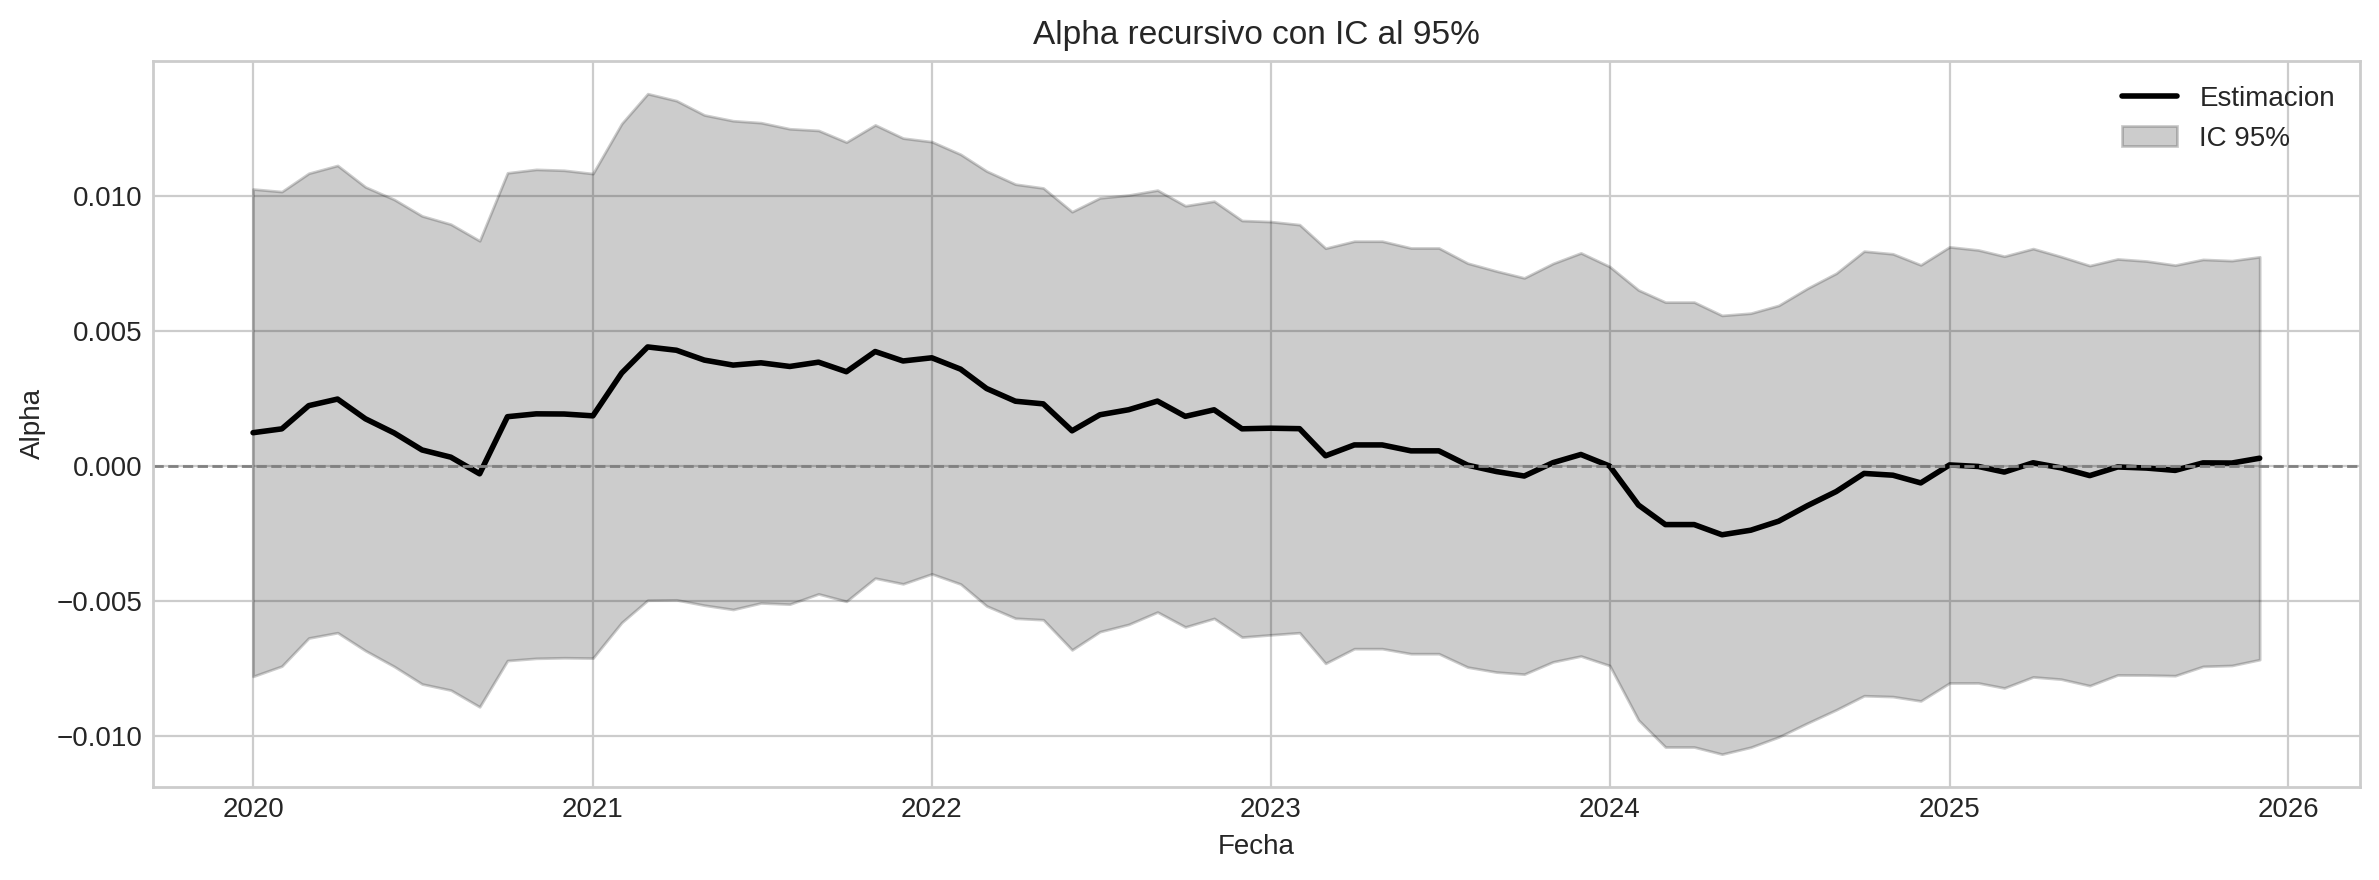

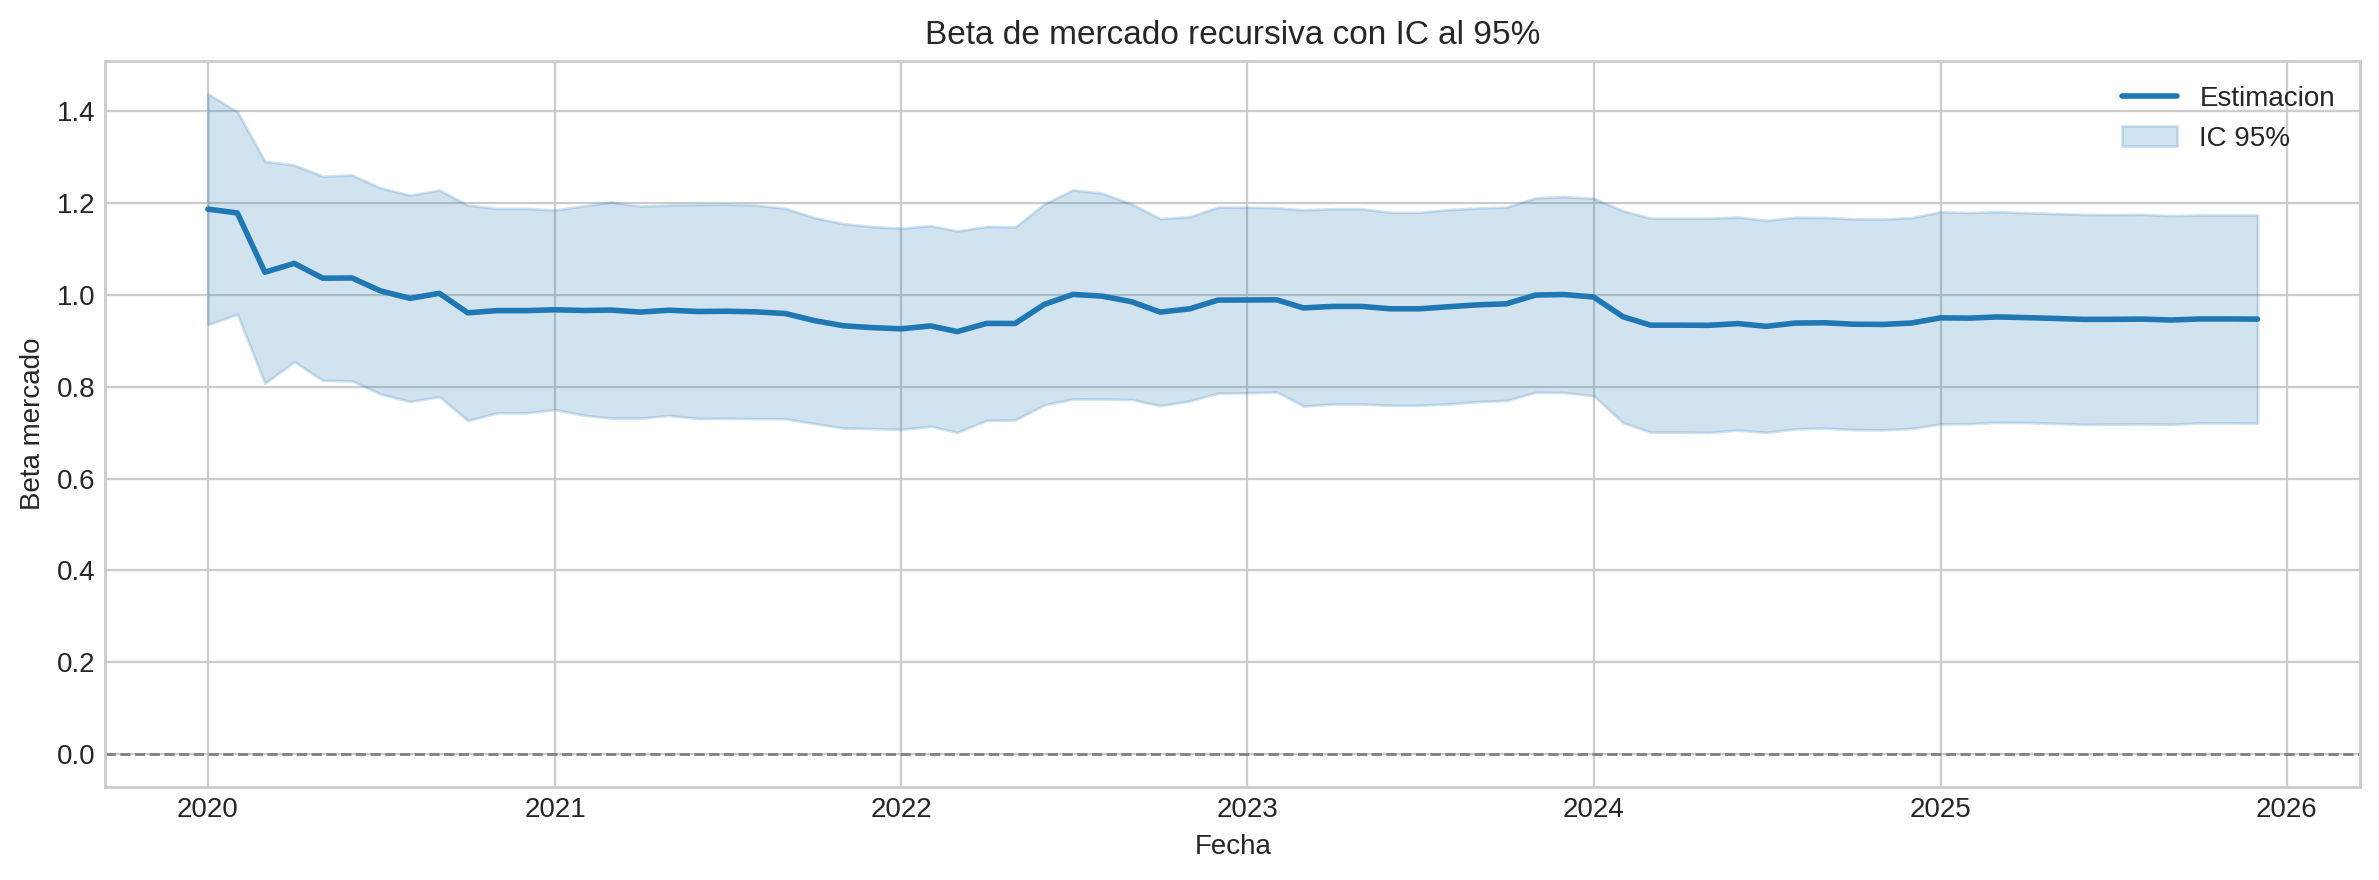

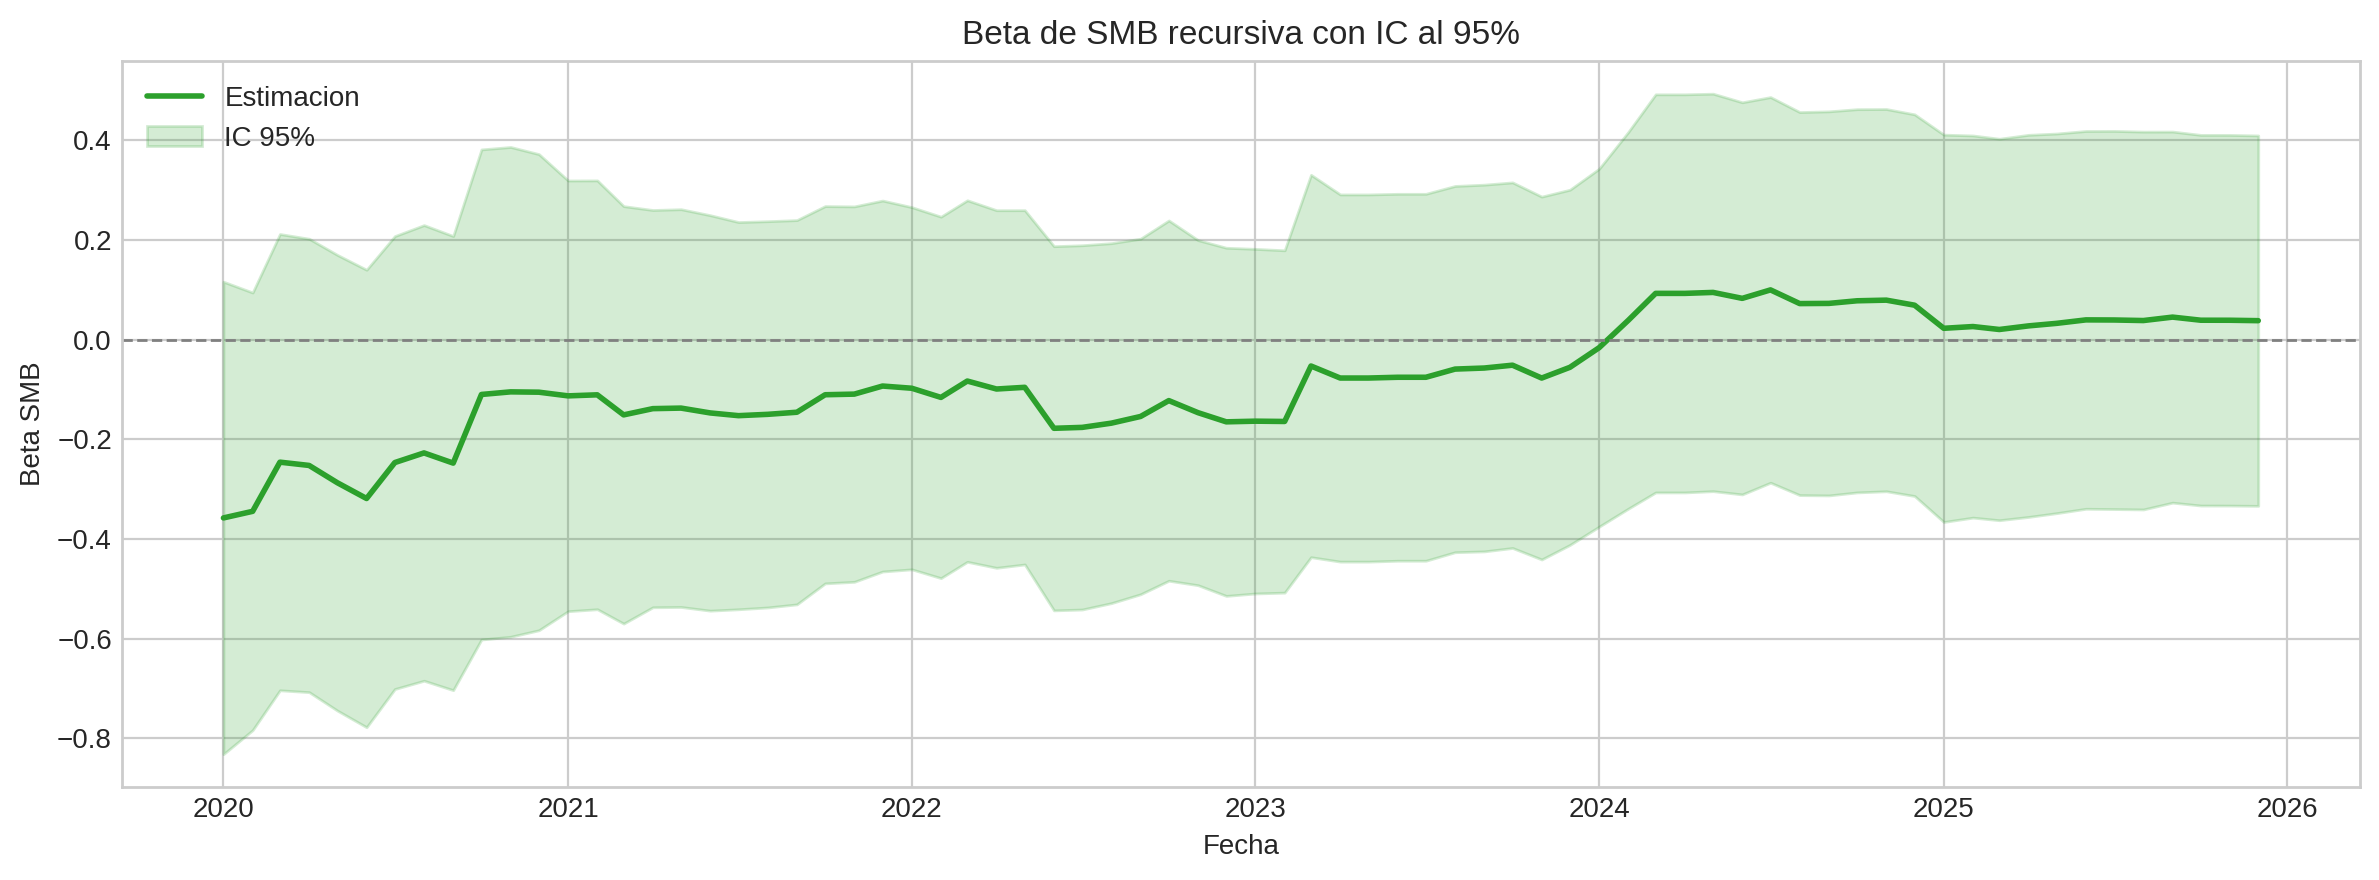

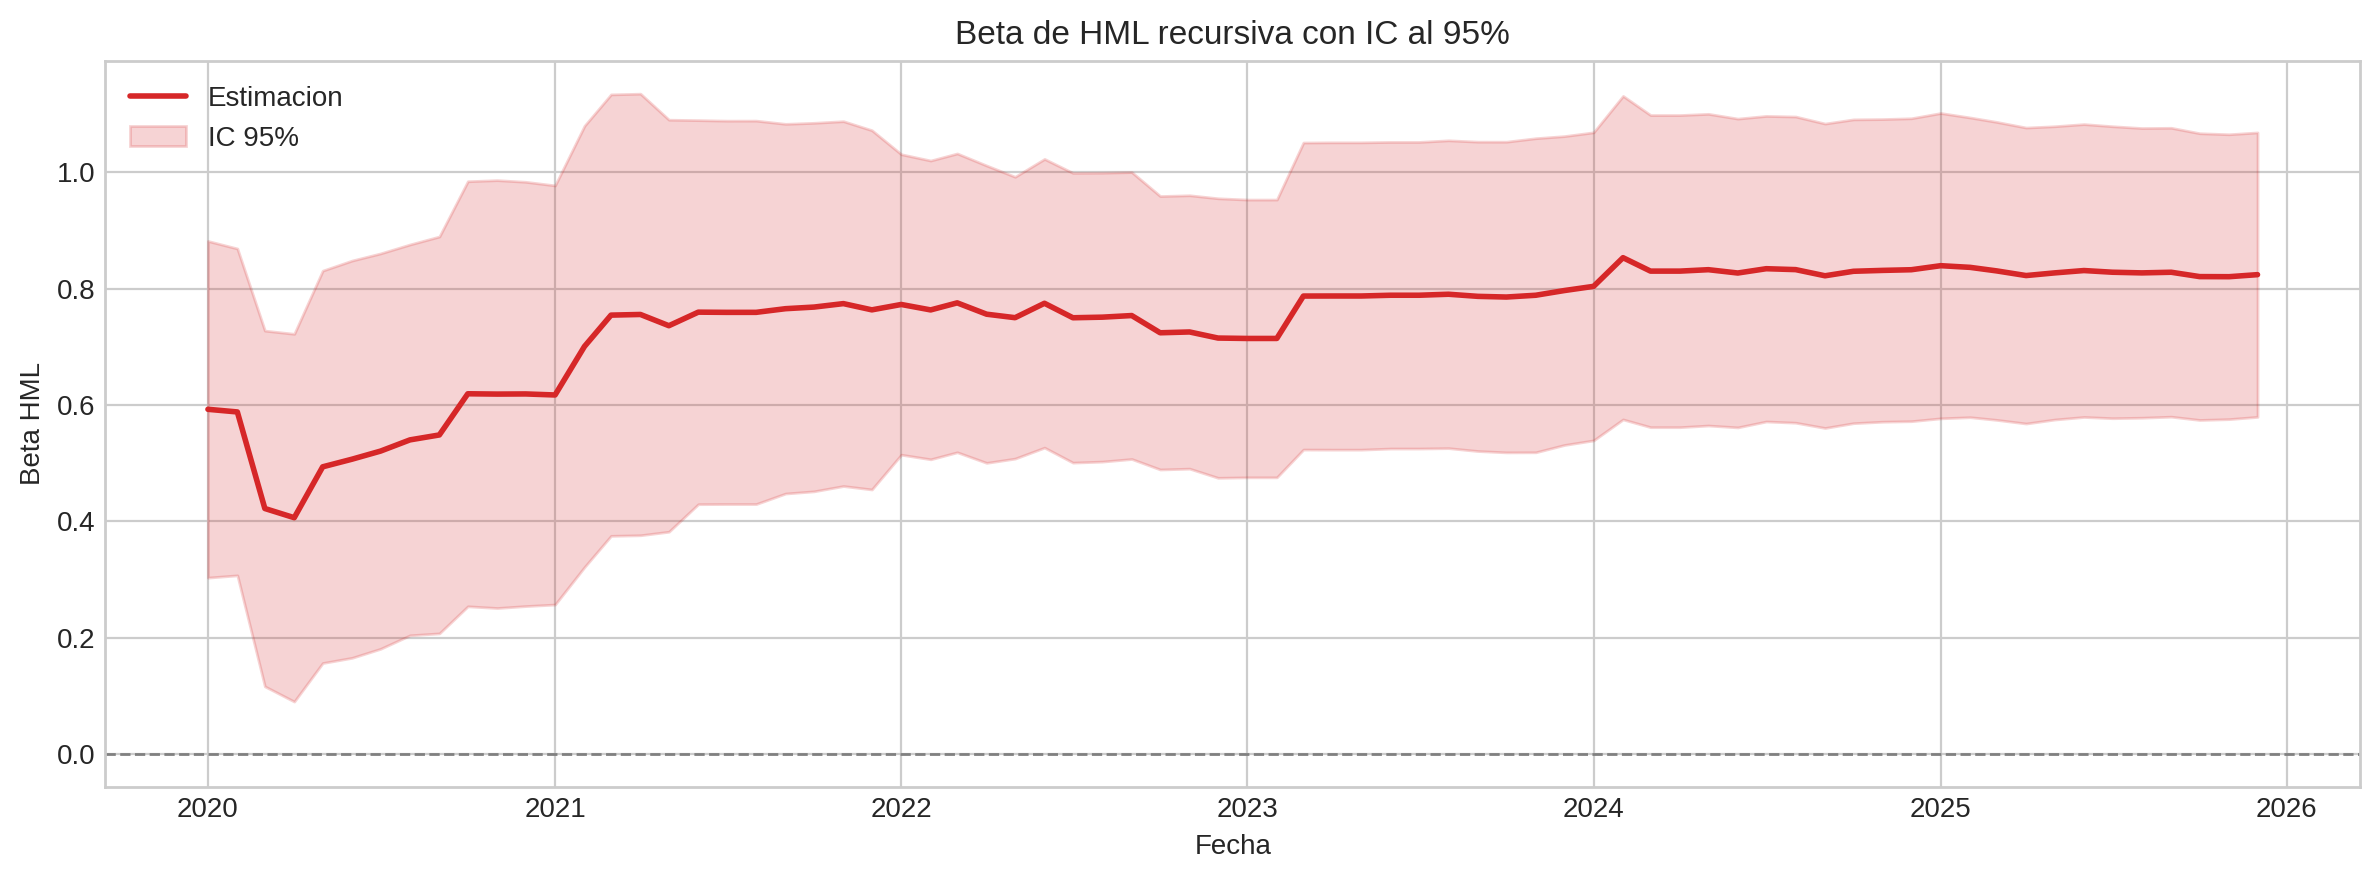

In [96]:
graficar_coeficiente_con_ic(resultados_recursivos, 'const', 'Alpha recursivo con IC al 95%', 'Alpha', 'black')
graficar_coeficiente_con_ic(resultados_recursivos, 'Market Premium', 'Beta de mercado recursiva con IC al 95%', 'Beta mercado', 'tab:blue')
graficar_coeficiente_con_ic(resultados_recursivos, 'SMB', 'Beta de SMB recursiva con IC al 95%', 'Beta SMB', 'tab:green')
graficar_coeficiente_con_ic(resultados_recursivos, 'HML', 'Beta de HML recursiva con IC al 95%', 'Beta HML', 'tab:red')

# **6. Comparacion entre la estimacion estatica y la ultima recursiva**

In [97]:
parametros = ['const', 'Market Premium', 'SMB', 'HML', 'intervencion', '2_intervencion', 'cre_riesgo_market']

comparacion = pd.DataFrame({
    'Estatica muestra completa': modelo_ff3_completo.params[parametros],
    'Ultima estimacion recursiva': resultados_recursivos[parametros].iloc[-1]
})

comparacion

,Estatica muestra completa,Ultima estimacion recursiva
const,0.0003,0.0003
Market Premium,0.9470,0.9470
SMB,0.0381,0.0381
HML,0.8241,0.8241
intervencion,0.2030,0.2030
2_intervencion,-0.1663,-0.1663
cre_riesgo_market,0.3552,0.3552
